# Lazazzara2018

### Carga inicial

In [1]:
# librerias
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../models")

def export_classifier(dataset_slug, model, feature_columns, label_encoder=None, meta=None):
    out = MODELS_DIR / dataset_slug
    out.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, out / "classifier.joblib")
    joblib.dump(list(feature_columns), out / "feature_columns.joblib")
    if label_encoder is not None:
        joblib.dump(label_encoder, out / "label_encoder.joblib")
    if meta:
        joblib.dump(meta, out / "classifier_meta.joblib")
    print(f"Exportado clasificador: {dataset_slug} -> {out}")

In [3]:
pd.set_option("display.max_columns", None)

# Cargar la tabla de muestras y el catalogo de compuestos 
con = sqlite3.connect("../db/tfm_vocs.db")
muestras_todas = pd.read_sql("SELECT * FROM muestras", con)
compuestos_todos = pd.read_sql("SELECT * FROM compuestos", con)
con.close()

# Cargar el parquet de abundancias
abundancias = pd.read_parquet("../db/data/processed/abundancias_lazazzara2018.parquet")

# Filtrar 
muestras = muestras_todas[muestras_todas["dataset_origin"] == "Lazazzara2018"].copy()
compuestos = compuestos_todos[compuestos_todos["dataset_origin"] == "Lazazzara2018"].copy()

print(f"muestras: {muestras.shape}")
print(f"compuestos: {compuestos.shape}")
print(f"abundancias: {abundancias.shape}")

print(f"\nFrecuencia de cada estado fisiologico: \n{muestras['physiological_state'].value_counts()}")

muestras: (98, 19)
compuestos: (52, 15)
abundancias: (5096, 4)

Frecuencia de cada estado fisiologico: 
physiological_state
control     50
infected    48
Name: count, dtype: int64


### Matriz de features

In [4]:
# Unir abundancias con  compuestos
abundancias_cid = abundancias.merge(
    compuestos[["compuesto_id", "pubchem_cid"]],
    on="compuesto_id",
    how="left"
)

print(f"Filas de abundancia sin cid: {abundancias_cid['pubchem_cid'].isna().sum()} de {len(abundancias_cid)}")

# Descartar las que no tienen CID 
abundancias_cid = abundancias_cid.dropna(subset=["pubchem_cid"])
abundancias_cid["pubchem_cid"] = abundancias_cid["pubchem_cid"].astype(int)

# Pivotear
matriz_features = abundancias_cid.pivot_table(
    index="sample_id",
    columns="pubchem_cid",
    values="abundancia",
    aggfunc="mean"
)

print(f"\nmatriz_features: {matriz_features.shape}")
print(f"Total de NaN: {matriz_features.isna().sum().sum()}")
print(f"Proporcion de NaN: {matriz_features.isna().mean().mean():.2%}")

Filas de abundancia sin cid: 1568 de 5096

matriz_features: (98, 36)
Total de NaN: 0
Proporcion de NaN: 0.00%


### Estandarización 

In [5]:
# z-score cada compuesto
from scipy.stats import zscore

matriz_zscore = matriz_features.apply(zscore)

print(f"matriz_zscore: {matriz_zscore.shape}")
print(f"NaN despues del z-score: {matriz_zscore.isna().sum().sum()}")

# Verificar que quedo bien centrado
print(f"\nMedia por compuesto:")
print(matriz_zscore.mean().describe())

matriz_zscore: (98, 36)
NaN despues del z-score: 0

Media por compuesto:
count    3.600000e+01
mean     4.697546e-17
std      1.305599e-16
min     -2.278329e-16
25%     -3.299515e-17
50%      3.058778e-17
75%      9.440082e-17
max      4.330436e-16
dtype: float64


### X e Y + Tr/Ts

In [6]:
# Unir la matriz con la var. objetivo
datos_modelo = muestras.set_index("sample_id")[["physiological_state"]].join(matriz_zscore)

X = datos_modelo.drop("physiological_state", axis=1)
y = datos_modelo["physiological_state"]

# Convertir los nombres de columna a str 
X.columns = X.columns.astype(str)

print(f"X: {X.shape}")
print(f"\nFrecuencia de cada clase: \n{y.value_counts(normalize=True)}")

X: (98, 36)

Frecuencia de cada clase: 
physiological_state
control     0.510204
infected    0.489796
Name: proportion, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=123
)

print(f"Frecuencia de cada clase en tr: \n{y_train.value_counts(normalize=True)}")
print(f"\nfrecuencia de cada clase en ts: \n{y_test.value_counts(normalize=True)}")
print(f"\nTamaño de tr: {X_train.shape[0]}, tamaño de ts: {X_test.shape[0]}")

Frecuencia de cada clase en tr: 
physiological_state
control     0.512821
infected    0.487179
Name: proportion, dtype: float64

frecuencia de cada clase en ts: 
physiological_state
control     0.5
infected    0.5
Name: proportion, dtype: float64

Tamaño de tr: 78, tamaño de ts: 20


## Arbol de decisión

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Crear el arbol de decision 
base_classifier = DecisionTreeClassifier(min_samples_split=10, criterion="gini", max_depth=5, random_state=123)
base_classifier.fit(X_train, y_train)
y_pred_base = base_classifier.predict(X_test)

accuracy_base = accuracy_score(y_test, y_pred_base)
print(f"Precision del arbol: {accuracy_base}")

print(f"\n{classification_report(y_test, y_pred_base, zero_division=0)}")

Precision del arbol: 0.85

              precision    recall  f1-score   support

     control       0.77      1.00      0.87        10
    infected       1.00      0.70      0.82        10

    accuracy                           0.85        20
   macro avg       0.88      0.85      0.85        20
weighted avg       0.88      0.85      0.85        20



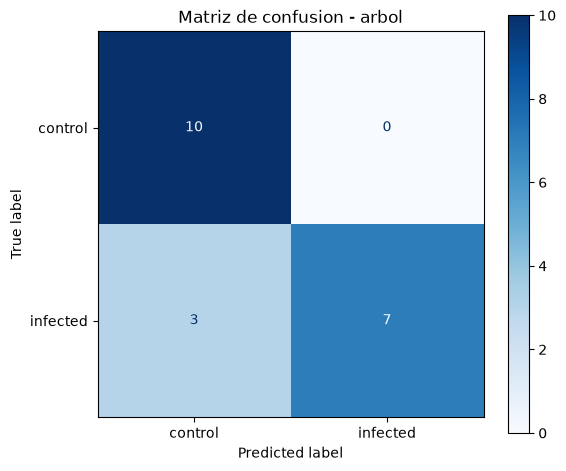

In [9]:
# matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    base_classifier, X_test, y_test,
    ax=ax, cmap="Blues"
)
plt.title("Matriz de confusion - arbol")
plt.tight_layout()
plt.show()

## Random forest

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

params_rf = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [3, 10],
    "criterion": ["gini", "entropy"],
}

scoring_metrics = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

grid_search_RF = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=123),
    param_grid=params_rf,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_RF.fit(X_train, y_train)

print(f"Mejores parametros (automatico): {grid_search_RF.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_RF.best_score_}")

Mejores parametros (automatico): {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 200}
Mejor f1_macro en CV: 0.7171428571428573


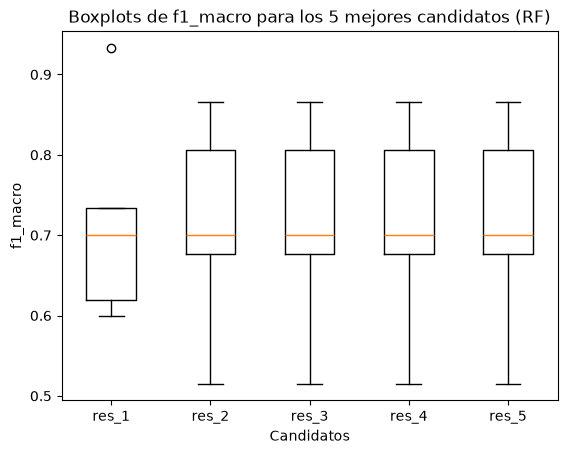

Parametros de cada UNO:
res_1: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 200}
res_2: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 150}
res_3: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
res_4: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
res_5: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 150}


In [11]:
# Top 5
resultados_cv = pd.DataFrame(grid_search_RF.cv_results_)
sorted_results = resultados_cv.sort_values(by="mean_test_f1_macro", ascending=False).head(5)

cols_folds = ["split0_test_f1_macro","split1_test_f1_macro","split2_test_f1_macro","split3_test_f1_macro","split4_test_f1_macro"]

res_1 = sorted_results[cols_folds].iloc[0]
res_2 = sorted_results[cols_folds].iloc[1]
res_3 = sorted_results[cols_folds].iloc[2]
res_4 = sorted_results[cols_folds].iloc[3]
res_5 = sorted_results[cols_folds].iloc[4]

plt.boxplot([res_1.values, res_2.values, res_3.values, res_4.values, res_5.values],
            tick_labels=["res_1","res_2","res_3","res_4","res_5"])
plt.title("Boxplots de f1_macro para los 5 mejores candidatos (RF)")
plt.xlabel("Candidatos")
plt.ylabel("f1_macro")
plt.show()

print("Parametros de cada UNO:")
for i in range(5):
    print(f"res_{i+1}: {sorted_results['params'].iloc[i]}")

Elijo res_1 (entropy, max_depth=5, min_samples_leaf=3, min_samples_split=10, n_estimators=200). Tiene el peor caso más alto que el resto (0.60 vs 0.52), y aunque su techo sea un poco menor, prefiero un modelo más parejo entre folds.

In [12]:
#Entrenar modelo con res_! y evaluar tr/ts
mejores_params_RF = sorted_results["params"].iloc[0]
print(f"Parametros elegidos: {mejores_params_RF}")

best_model_RF = RandomForestClassifier(**mejores_params_RF, class_weight="balanced", random_state=123)
best_model_RF.fit(X_train, y_train)

y_train_pred_rf = best_model_RF.predict(X_train)
y_test_pred_rf = best_model_RF.predict(X_test)

print(f"\nF1 macro en train: {f1_score(y_train, y_train_pred_rf, average='macro')}")
print(f"F1 macro en test: {f1_score(y_test, y_test_pred_rf, average='macro')}")


print(f"\n{classification_report(y_test, y_test_pred_rf, zero_division=0)}")

Parametros elegidos: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 200}

F1 macro en train: 0.9871773795824429
F1 macro en test: 0.797979797979798

              precision    recall  f1-score   support

     control       0.75      0.90      0.82        10
    infected       0.88      0.70      0.78        10

    accuracy                           0.80        20
   macro avg       0.81      0.80      0.80        20
weighted avg       0.81      0.80      0.80        20



## XGBoost

In [13]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb_classifier = XGBClassifier(
    booster="gbtree", n_estimators=200,
    eta=0.1, gamma=1, max_depth=15,
    tree_method="hist", random_state=123
)
xgb_classifier.fit(X_train, y_train_enc)
y_pred_base_xgb = xgb_classifier.predict(X_test)

accuracy_xgb = accuracy_score(y_test_enc, y_pred_base_xgb)
print(f"Precision de XGBoost base: {accuracy_xgb}")
print(f"\n{classification_report(y_test_enc, y_pred_base_xgb, target_names=le.classes_, zero_division=0)}")

Precision de XGBoost base: 0.85

              precision    recall  f1-score   support

     control       0.77      1.00      0.87        10
    infected       1.00      0.70      0.82        10

    accuracy                           0.85        20
   macro avg       0.88      0.85      0.85        20
weighted avg       0.88      0.85      0.85        20



In [14]:
# Ver sobreajuste
y_train_pred_xgb = xgb_classifier.predict(X_train)
print(f"Accuracy en train: {accuracy_score(y_train_enc, y_train_pred_xgb)}")
print(f"Accuracy en test: {accuracy_score(y_test_enc, y_pred_base_xgb)}")

Accuracy en train: 0.9743589743589743
Accuracy en test: 0.85


In [15]:
#Gridsearch
params_xgb = {
    "n_estimators": [50, 100, 150],
    "eta": [0.05, 0.1, 0.2],
    "gamma": [0.1, 0.5, 1],
    "max_depth": [2, 3, 5],
}

grid_search_XGB = GridSearchCV(
    estimator=XGBClassifier(booster="gbtree", tree_method="hist", random_state=123),
    param_grid=params_xgb,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_XGB.fit(X_train, y_train_enc)

print(f"\nMejores parametros: {grid_search_XGB.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_XGB.best_score_}")


Mejores parametros: {'eta': 0.05, 'gamma': 1, 'max_depth': 2, 'n_estimators': 150}
Mejor f1_macro en CV: 0.8326984126984126


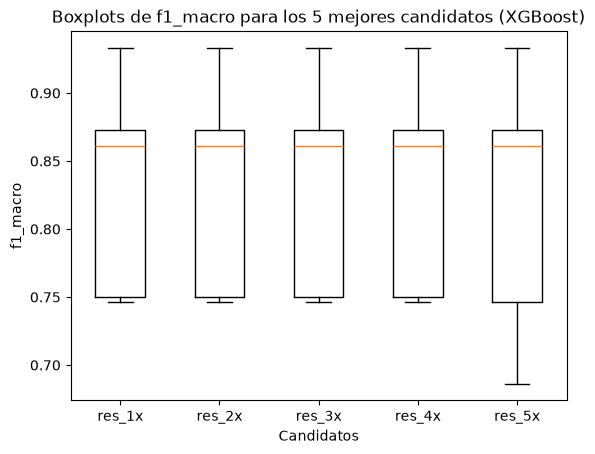

Parametros de cada uno:
res_1x: {'eta': 0.05, 'gamma': 1, 'max_depth': 2, 'n_estimators': 150}
res_2x: {'eta': 0.1, 'gamma': 1, 'max_depth': 2, 'n_estimators': 150}
res_3x: {'eta': 0.1, 'gamma': 1, 'max_depth': 2, 'n_estimators': 50}
res_4x: {'eta': 0.1, 'gamma': 1, 'max_depth': 2, 'n_estimators': 100}
res_5x: {'eta': 0.05, 'gamma': 1, 'max_depth': 2, 'n_estimators': 100}


In [16]:
#Top 5
resultados_cv_xgb = pd.DataFrame(grid_search_XGB.cv_results_)
sorted_results_xgb = resultados_cv_xgb.sort_values(by="mean_test_f1_macro", ascending=False).head(5)

res_1x = sorted_results_xgb[cols_folds].iloc[0]
res_2x = sorted_results_xgb[cols_folds].iloc[1]
res_3x = sorted_results_xgb[cols_folds].iloc[2]
res_4x = sorted_results_xgb[cols_folds].iloc[3]
res_5x = sorted_results_xgb[cols_folds].iloc[4]

plt.boxplot([res_1x.values, res_2x.values, res_3x.values, res_4x.values, res_5x.values],
            tick_labels=["res_1x","res_2x","res_3x","res_4x","res_5x"])
plt.title("Boxplots de f1_macro para los 5 mejores candidatos (XGBoost)")
plt.xlabel("Candidatos")
plt.ylabel("f1_macro")
plt.show()

print("Parametros de cada uno:")
for i in range(5):
    print(f"res_{i+1}x: {sorted_results_xgb['params'].iloc[i]}")

res_1x a res_4x dan prácticamente lo mismo. Descarto res_5x porque tiene el peor caso más bajo de los 5. Me quedo con res_1x

In [17]:
# Entrenar el modelo con res_1x
mejores_params_XGB = sorted_results_xgb["params"].iloc[0]
print(f"Parametros elegidos: {mejores_params_XGB}")

best_model_XGB = XGBClassifier(**mejores_params_XGB, booster="gbtree", tree_method="hist", random_state=123)
best_model_XGB.fit(X_train, y_train_enc)

y_train_pred_xgb_best = best_model_XGB.predict(X_train)
y_test_pred_xgb_best = best_model_XGB.predict(X_test)

print(f"\nF1 macro en train: {f1_score(y_train_enc, y_train_pred_xgb_best, average='macro')}")
print(f"F1 macro en test: {f1_score(y_test_enc, y_test_pred_xgb_best, average='macro')}")

print(f"\n{classification_report(y_test_enc, y_test_pred_xgb_best, target_names=le.classes_, zero_division=0)}")

Parametros elegidos: {'eta': 0.05, 'gamma': 1, 'max_depth': 2, 'n_estimators': 150}

F1 macro en train: 0.9743421052631579
F1 macro en test: 0.7916666666666667

              precision    recall  f1-score   support

     control       0.71      1.00      0.83        10
    infected       1.00      0.60      0.75        10

    accuracy                           0.80        20
   macro avg       0.86      0.80      0.79        20
weighted avg       0.86      0.80      0.79        20



In [18]:
# Tabla resúmen 

resumen_modelos = pd.DataFrame([
    {
        "modelo": "Arbol de decision (base)",
        "f1_macro_train": f1_score(y_train, base_classifier.predict(X_train), average="macro"),
        "f1_macro_test": f1_score(y_test, y_pred_base, average="macro"),
        "accuracy_test": accuracy_score(y_test, y_pred_base),
    },
    {
        "modelo": "Random Forest (tuneado)",
        "f1_macro_train": f1_score(y_train, y_train_pred_rf, average="macro"),
        "f1_macro_test": f1_score(y_test, y_test_pred_rf, average="macro"),
        "accuracy_test": accuracy_score(y_test, y_test_pred_rf),
    },
    {
        "modelo": "XGBoost (tuneado)",
        "f1_macro_train": f1_score(y_train_enc, y_train_pred_xgb_best, average="macro"),
        "f1_macro_test": f1_score(y_test_enc, y_test_pred_xgb_best, average="macro"),
        "accuracy_test": accuracy_score(y_test_enc, y_test_pred_xgb_best),
    },
])

# Calcular indicador de sobreajuste
resumen_modelos["gap_sobreajuste"] = resumen_modelos["f1_macro_train"] - resumen_modelos["f1_macro_test"]
print(resumen_modelos.round(3).to_string(index=False))

                  modelo  f1_macro_train  f1_macro_test  accuracy_test  gap_sobreajuste
Arbol de decision (base)           0.987          0.847           0.85            0.141
 Random Forest (tuneado)           0.987          0.798           0.80            0.189
       XGBoost (tuneado)           0.974          0.792           0.80            0.183


Me quedo con el árbol simple. Ni RF (0.798) ni XGBoost (0.792) le ganan al árbol (0.80), con los tres comparados bajo el mismo protocolo. Con una señal tan clara entre control e infectado, un modelo más complejo no suma, Además, el balanceo de clases de RF puede estar metiendo ruido de más.

## SHAP

In [19]:
import shap

# Para un arbol de decision 
explainer = shap.TreeExplainer(base_classifier)
shap_values = explainer.shap_values(X_test)

print(f"Forma de shap_values: {np.array(shap_values).shape}")
print(f"Forma de X_test: {X_test.shape}")

Forma de shap_values: (20, 36, 2)
Forma de X_test: (20, 36)


C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
# Usar los shap values de la clase infected 
shap_values_array = np.array(shap_values) 

idx_infected = 1  

shap_infected = shap_values_array[:, :, idx_infected]

importancia = pd.Series(
    np.abs(shap_infected).mean(axis=0), index=X_test.columns
).sort_values(ascending=False)

print("Top 15 compuestos mas importantes infected/control:")
print(importancia.head(15))

# Identifico los nombres
top_cids = [int(c) for c in importancia.head(15).index]
nombres_top = compuestos[compuestos["pubchem_cid"].isin(top_cids)][
    ["pubchem_cid", "name_original"]
].drop_duplicates(subset=["pubchem_cid"])
print("\nNombres:")
print(nombres_top.to_string(index=False))

Top 15 compuestos mas importantes infected/control:
441005     0.289722
549664     0.155944
6782       0.114293
637564     0.048776
957        0.017736
92313      0.016219
5364752    0.014213
244        0.000000
6054       0.000000
998        0.000000
6549       0.000000
6184       0.000000
18554      0.000000
19602      0.000000
23204      0.000000
dtype: float64

Nombres:
 pubchem_cid                                                          name_original
   5364752.0                                                trans-2-Pentenal Std_02
     92313.0                                        gamma-Cadinene Valentina?160219
    441005.0                                   delta-Cadinene (vitis berry_stem)_31
      6549.0 beta-Linalool (vitis whole plant_leave_berry_flower_stem_skin_mesh)_27
     23204.0                             alpha-Caryophyllene (vitis flower_stem)_15
      6184.0                         Hexanal (vitis leave_ berry_stem_skin_mesh)_24
      6782.0                       

In [21]:
# Excluyo Diisobutyl phthalate, es un contaminante de laboratorio  

cols_sin_ftalato = [c for c in X_train.columns if c != "6782"]
X_train_limpio = X_train[cols_sin_ftalato]
X_test_limpio = X_test[cols_sin_ftalato]

# Re-entrenar el arbol de decision
base_classifier_limpio = DecisionTreeClassifier(min_samples_split=10, criterion="gini", max_depth=5, random_state=123)
base_classifier_limpio.fit(X_train_limpio, y_train)
y_pred_limpio = base_classifier_limpio.predict(X_test_limpio)

print(f"Accuracy sin ftalato: {accuracy_score(y_test, y_pred_limpio)}")
print(f"\n{classification_report(y_test, y_pred_limpio, zero_division=0)}")

Accuracy sin ftalato: 0.8

              precision    recall  f1-score   support

     control       0.75      0.90      0.82        10
    infected       0.88      0.70      0.78        10

    accuracy                           0.80        20
   macro avg       0.81      0.80      0.80        20
weighted avg       0.81      0.80      0.80        20



In [22]:
# Revisar si hay otros posibles contaminantes 

posibles_contaminantes = compuestos[
    compuestos["name_original"].str.contains(
        "phthalate|siloxane|silane|BHT|butylated hydroxytoluene",
        case=False, na=False
    )
]

print("Posibles contaminantes:")
print(posibles_contaminantes[["pubchem_cid", "name_original"]].to_string(index=False))

Posibles contaminantes:
 pubchem_cid           name_original
      6782.0 Diisobutyl phthalate_04


In [23]:
# SHAP sobre modelo limpio
explainer_limpio = shap.TreeExplainer(base_classifier_limpio)
shap_values_limpio = explainer_limpio.shap_values(X_test_limpio)

shap_values_array_limpio = np.array(shap_values_limpio)
shap_infected_limpio = shap_values_array_limpio[:, :, 1]  # clase 'infected'

importancia_limpia = pd.Series(
    np.abs(shap_infected_limpio).mean(axis=0), index=X_test_limpio.columns
).sort_values(ascending=False)

print("Top 15 compuestos (modelo limpio):")
print(importancia_limpia.head(15))

top_cids_limpio = [int(c) for c in importancia_limpia.head(15).index]
nombres_limpio = compuestos[compuestos["pubchem_cid"].isin(top_cids_limpio)][
    ["pubchem_cid", "name_original"]
].drop_duplicates(subset=["pubchem_cid"])
print("\nNombres:")
print(nombres_limpio.to_string(index=False))

Top 15 compuestos (modelo limpio):
441005     0.259099
549664     0.182103
18554      0.069234
637564     0.048776
6428573    0.042277
5283321    0.037521
244        0.000000
998        0.000000
957        0.000000
6549       0.000000
6054       0.000000
19602      0.000000
20861      0.000000
23204      0.000000
6184       0.000000
dtype: float64

Nombres:
 pubchem_cid                                                          name_original
    441005.0                                   delta-Cadinene (vitis berry_stem)_31
      6549.0 beta-Linalool (vitis whole plant_leave_berry_flower_stem_skin_mesh)_27
     23204.0                             alpha-Caryophyllene (vitis flower_stem)_15
   6428573.0              LINALOOL OXIDE (2) (vitis leave_stem_mesh_whole plant)_01
      6184.0                         Hexanal (vitis leave_ berry_stem_skin_mesh)_24
     20861.0                                                  Ethyl-benzaldehyde_02
       244.0                     Benzyl Alcohol (vit

In [24]:
export_classifier(
    "lazazzara2018",
    model=base_classifier_limpio,
    feature_columns=X_train_limpio.columns,
    meta={"especie": "Vitis vinifera", "modelo": "Arbol de decision", "f1_macro_test": 0.80}
)

Exportado clasificador: lazazzara2018 -> ..\models\lazazzara2018


# Laupheimer2024

### Carga de datos

In [25]:
# Filtrar muestras y compuestos
muestras = muestras_todas[muestras_todas["dataset_origin"] == "Laupheimer2024"].copy()
compuestos = compuestos_todos[compuestos_todos["dataset_origin"] == "Laupheimer2024"].copy()
abundancias = pd.read_parquet("../db/data/processed/abundancias_laupheimer2024.parquet")

print(f"muestras: {muestras.shape}")
print(f"compuestos: {compuestos.shape}")
print(f"abundancias: {abundancias.shape}")

print(f"\nFrecuencia de cada estado fisiologico: \n{muestras['physiological_state'].value_counts()}")

# Chequear contaminantes
posibles_contaminantes = compuestos[
    compuestos["name_original"].str.contains(
        "phthalate|siloxane|silane|BHT|butylated hydroxytoluene",
        case=False, na=False
    )
]
print(f"\nPosibles contaminantes: {len(posibles_contaminantes)}")
if len(posibles_contaminantes) > 0:
    print(posibles_contaminantes[["pubchem_cid", "name_original"]].to_string(index=False))

muestras: (32, 19)
compuestos: (25, 15)
abundancias: (800, 4)

Frecuencia de cada estado fisiologico: 
physiological_state
control     16
infected    16
Name: count, dtype: int64

Posibles contaminantes: 0


### Matriz de abundancias

In [26]:
# Unir abundancias con compuestos
abundancias_cid = abundancias.merge(
    compuestos[["compuesto_id", "pubchem_cid"]],
    on="compuesto_id",
    how="left"
)

print(f"Filas de abundancia sin cid: {abundancias_cid['pubchem_cid'].isna().sum()} de {len(abundancias_cid)}")

# Descarto las que no tienen CID 
abundancias_cid = abundancias_cid.dropna(subset=["pubchem_cid"])
abundancias_cid["pubchem_cid"] = abundancias_cid["pubchem_cid"].astype(int)

# Pivotear
matriz_features = abundancias_cid.pivot_table(
    index="sample_id",
    columns="pubchem_cid",
    values="abundancia",
    aggfunc="mean"
)

print(f"\nmatriz_features: {matriz_features.shape}")
print(f"Total de NaN: {matriz_features.isna().sum().sum()}")

Filas de abundancia sin cid: 0 de 800

matriz_features: (32, 25)
Total de NaN: 378


In [27]:
#Muchos missings. Revisar como se distribuye
print("Proporcion de missing por compuesto:")
print((matriz_features.isna().sum() / len(matriz_features)).sort_values(ascending=False))

print("\nProporcion de missing por muestra:")
print((matriz_features.isna().sum(axis=1) / matriz_features.shape[1]).describe())

Proporcion de missing por compuesto:
pubchem_cid
9862       0.90625
7463       0.87500
26375      0.84375
31289      0.78125
7720       0.75000
6654       0.75000
11520      0.71875
6448       0.68750
26058      0.68750
8175       0.62500
7802       0.62500
4133       0.53125
5281515    0.50000
5363388    0.43750
12389      0.40625
8182       0.40625
22311      0.37500
17835      0.31250
5281167    0.28125
6549       0.18750
6616       0.06250
16666      0.03125
2758       0.03125
2537       0.00000
8141       0.00000
dtype: float64

Proporcion de missing por muestra:
count    32.000000
mean      0.472500
std       0.199208
min       0.040000
25%       0.280000
50%       0.520000
75%       0.640000
max       0.720000
dtype: float64


### Estandarización

In [28]:
# Tratar el missing como no detectado 

matriz_features_rf = matriz_features.fillna(0)

# z-score sobre la version imputada 
matriz_zscore_rf = matriz_features_rf.apply(zscore)

# z-score sobre la version con NaN
matriz_zscore_xgb = (matriz_features - matriz_features.mean()) / matriz_features.std()

print(f"NaN en matriz_zscore_rf: {matriz_zscore_rf.isna().sum().sum()}")
print(f"NaN en matriz_zscore_xgb: {matriz_zscore_xgb.isna().sum().sum()}")

NaN en matriz_zscore_rf: 0
NaN en matriz_zscore_xgb: 378


### X e Y + Tr/Ts

In [29]:
# Version arbol/RF (imputada con 0)
datos_modelo_rf = muestras.set_index("sample_id")[["physiological_state"]].join(matriz_zscore_rf)
X_rf = datos_modelo_rf.drop("physiological_state", axis=1)
X_rf.columns = X_rf.columns.astype(str)
y_rf = datos_modelo_rf["physiological_state"]

# Version XGBoost (con NaN )
datos_modelo_xgb = muestras.set_index("sample_id")[["physiological_state"]].join(matriz_zscore_xgb)
X_xgb = datos_modelo_xgb.drop("physiological_state", axis=1)
X_xgb.columns = X_xgb.columns.astype(str)
y_xgb = datos_modelo_xgb["physiological_state"]

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, stratify=y_rf, random_state=123
)
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=0.2, stratify=y_xgb, random_state=123
)

print(f"Mismo splits: {(y_train_rf.values == y_train_xgb.values).all()}")
print(f"\nFrecuencia en tr: \n{y_train_rf.value_counts()}")
print(f"\nFrecuencia en ts: \n{y_test_rf.value_counts()}")

Mismo splits: True

Frecuencia en tr: 
physiological_state
infected    13
control     12
Name: count, dtype: int64

Frecuencia en ts: 
physiological_state
control     4
infected    3
Name: count, dtype: int64


## Arbol de decisión

In [30]:
base_classifier_cebada = DecisionTreeClassifier(min_samples_split=10, criterion="gini", max_depth=5, random_state=123)
base_classifier_cebada.fit(X_train_rf, y_train_rf)
y_pred_base_cebada = base_classifier_cebada.predict(X_test_rf)

print(f"Precision del arbol estandar: {accuracy_score(y_test_rf, y_pred_base_cebada)}")
print(f"\n{classification_report(y_test_rf, y_pred_base_cebada, zero_division=0)}")

Precision del arbol estandar: 0.5714285714285714

              precision    recall  f1-score   support

     control       0.60      0.75      0.67         4
    infected       0.50      0.33      0.40         3

    accuracy                           0.57         7
   macro avg       0.55      0.54      0.53         7
weighted avg       0.56      0.57      0.55         7



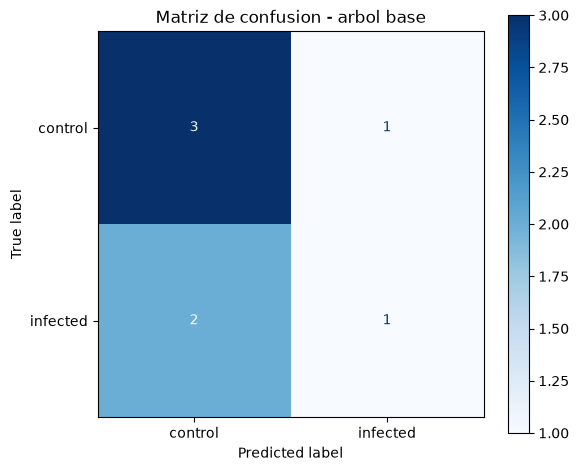

In [31]:
#MC
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    base_classifier_cebada, X_test_rf, y_test_rf,
    ax=ax, cmap="Blues"
)
plt.title("Matriz de confusion - arbol base")
plt.tight_layout()
plt.show()

## RandomForest

In [32]:
grid_search_RF_cebada = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=123),
    param_grid=params_rf,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_RF_cebada.fit(X_train_rf, y_train_rf)

print(f"Mejores parametros: {grid_search_RF_cebada.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_RF_cebada.best_score_}")

C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Mejores parametros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 50}
Mejor f1_macro en CV: 0.7166666666666667


C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


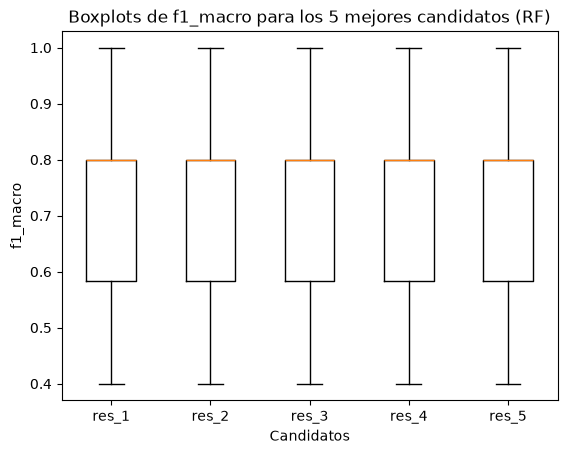

Parametros de cada uno:
res_1: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 50}
res_2: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
res_3: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 150}
res_4: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}
res_5: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 100}


In [33]:
#top5
resultados_cv_rf_cebada = pd.DataFrame(grid_search_RF_cebada.cv_results_)
sorted_results_rf_cebada = resultados_cv_rf_cebada.sort_values(by="mean_test_f1_macro", ascending=False).head(5)

res_1c = sorted_results_rf_cebada[cols_folds].iloc[0]
res_2c = sorted_results_rf_cebada[cols_folds].iloc[1]
res_3c = sorted_results_rf_cebada[cols_folds].iloc[2]
res_4c = sorted_results_rf_cebada[cols_folds].iloc[3]
res_5c = sorted_results_rf_cebada[cols_folds].iloc[4]

plt.boxplot([res_1c.values, res_2c.values, res_3c.values, res_4c.values, res_5c.values],
            tick_labels=["res_1","res_2","res_3","res_4","res_5"])
plt.title("Boxplots de f1_macro para los 5 mejores candidatos (RF)")
plt.xlabel("Candidatos")
plt.ylabel("f1_macro")
plt.show()

print("Parametros de cada uno:")
for i in range(5):
    print(f"res_{i+1}: {sorted_results_rf_cebada['params'].iloc[i]}")

Los 5 candidatos son equivalentes, elijo res_1

In [34]:
#Entrenar modelo con res_1
mejores_params_RF_cebada = sorted_results_rf_cebada["params"].iloc[0]
best_model_RF_cebada = RandomForestClassifier(**mejores_params_RF_cebada, class_weight="balanced", random_state=123)
best_model_RF_cebada.fit(X_train_rf, y_train_rf)

y_train_pred_rf_cebada = best_model_RF_cebada.predict(X_train_rf)
y_test_pred_rf_cebada = best_model_RF_cebada.predict(X_test_rf)

print(f"F1 macro en train: {f1_score(y_train_rf, y_train_pred_rf_cebada, average='macro')}")
print(f"F1 macro en test: {f1_score(y_test_rf, y_test_pred_rf_cebada, average='macro')}")

print(f"\n{classification_report(y_test_rf, y_test_pred_rf_cebada, zero_division=0)}")

F1 macro en train: 0.9597423510466989
F1 macro en test: 0.5333333333333333

              precision    recall  f1-score   support

     control       1.00      0.25      0.40         4
    infected       0.50      1.00      0.67         3

    accuracy                           0.57         7
   macro avg       0.75      0.62      0.53         7
weighted avg       0.79      0.57      0.51         7



## XGBoost

In [35]:
y_train_xgb_enc_cebada = le.fit_transform(y_train_xgb)
y_test_xgb_enc_cebada = le.transform(y_test_xgb)

xgb_classifier_cebada = XGBClassifier(
    booster="gbtree", n_estimators=200,
    eta=0.1, gamma=1, max_depth=15,
    tree_method="hist", random_state=123
)
xgb_classifier_cebada.fit(X_train_xgb, y_train_xgb_enc_cebada)
y_pred_base_xgb_cebada = xgb_classifier_cebada.predict(X_test_xgb)

print(f"Precision de XGBoost base: {accuracy_score(y_test_xgb_enc_cebada, y_pred_base_xgb_cebada)}")
print(f"\n{classification_report(y_test_xgb_enc_cebada, y_pred_base_xgb_cebada, target_names=le.classes_, zero_division=0)}")

Precision de XGBoost base: 0.42857142857142855

              precision    recall  f1-score   support

     control       0.50      0.50      0.50         4
    infected       0.33      0.33      0.33         3

    accuracy                           0.43         7
   macro avg       0.42      0.42      0.42         7
weighted avg       0.43      0.43      0.43         7



In [36]:
grid_search_XGB_cebada = GridSearchCV(
    estimator=XGBClassifier(booster="gbtree", tree_method="hist", random_state=123),
    param_grid=params_xgb,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_XGB_cebada.fit(X_train_xgb, y_train_xgb_enc_cebada)

print(f"Mejores parametros: {grid_search_XGB_cebada.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_XGB_cebada.best_score_}")

Mejores parametros: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 2, 'n_estimators': 100}
Mejor f1_macro en CV: 0.7057142857142857


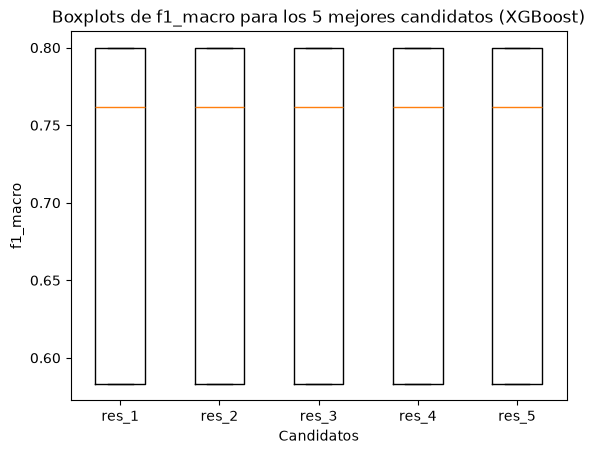

Parametros de cada uno:
res_1xc: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 2, 'n_estimators': 100}
res_2xc: {'eta': 0.05, 'gamma': 0.5, 'max_depth': 3, 'n_estimators': 100}
res_3xc: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 3, 'n_estimators': 100}
res_4xc: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 5, 'n_estimators': 100}
res_5xc: {'eta': 0.05, 'gamma': 0.5, 'max_depth': 5, 'n_estimators': 100}


In [37]:
#top5
resultados_cv_xgb_cebada = pd.DataFrame(grid_search_XGB_cebada.cv_results_)
sorted_results_xgb_cebada = resultados_cv_xgb_cebada.sort_values(by="mean_test_f1_macro", ascending=False).head(5)

res_1xc = sorted_results_xgb_cebada[cols_folds].iloc[0]
res_2xc = sorted_results_xgb_cebada[cols_folds].iloc[1]
res_3xc = sorted_results_xgb_cebada[cols_folds].iloc[2]
res_4xc = sorted_results_xgb_cebada[cols_folds].iloc[3]
res_5xc = sorted_results_xgb_cebada[cols_folds].iloc[4]

plt.boxplot([res_1xc.values, res_2xc.values, res_3xc.values, res_4xc.values, res_5xc.values],
            tick_labels=["res_1","res_2","res_3","res_4","res_5"])
plt.title("Boxplots de f1_macro para los 5 mejores candidatos (XGBoost)")
plt.xlabel("Candidatos")
plt.ylabel("f1_macro")
plt.show()

print("Parametros de cada uno:")
for i in range(5):
    print(f"res_{i+1}xc: {sorted_results_xgb_cebada['params'].iloc[i]}")

Los 5 candidatos son equivalentes, elijo res_1xc 

In [38]:
mejores_params_XGB_cebada = sorted_results_xgb_cebada["params"].iloc[0]
best_model_XGB_cebada = XGBClassifier(**mejores_params_XGB_cebada, booster="gbtree", tree_method="hist", random_state=123)
best_model_XGB_cebada.fit(X_train_xgb, y_train_xgb_enc_cebada)

y_train_pred_xgb_cebada = best_model_XGB_cebada.predict(X_train_xgb)
y_test_pred_xgb_cebada = best_model_XGB_cebada.predict(X_test_xgb)

print(f"F1 macro en train: {f1_score(y_train_xgb_enc_cebada, y_train_pred_xgb_cebada, average='macro')}")
print(f"F1 macro en test: {f1_score(y_test_xgb_enc_cebada, y_test_pred_xgb_cebada, average='macro')}")

print(f"\n{classification_report(y_test_xgb_enc_cebada, y_test_pred_xgb_cebada, target_names=le.classes_, zero_division=0)}")

F1 macro en train: 1.0
F1 macro en test: 0.41666666666666663

              precision    recall  f1-score   support

     control       0.50      0.50      0.50         4
    infected       0.33      0.33      0.33         3

    accuracy                           0.43         7
   macro avg       0.42      0.42      0.42         7
weighted avg       0.43      0.43      0.43         7



In [39]:
# Tabla resumen
resumen_modelos_cebada = pd.DataFrame([
    {
        "modelo": "Arbol de decision (base)",
        "f1_macro_train": f1_score(y_train_rf, base_classifier_cebada.predict(X_train_rf), average="macro"),
        "f1_macro_test": f1_score(y_test_rf, y_pred_base_cebada, average="macro"),
        "accuracy_test": accuracy_score(y_test_rf, y_pred_base_cebada),
    },
    {
        "modelo": "Random Forest (tuneado)",
        "f1_macro_train": f1_score(y_train_rf, y_train_pred_rf_cebada, average="macro"),
        "f1_macro_test": f1_score(y_test_rf, y_test_pred_rf_cebada, average="macro"),
        "accuracy_test": accuracy_score(y_test_rf, y_test_pred_rf_cebada),
    },
    {
        "modelo": "XGBoost (tuneado)",
        "f1_macro_train": f1_score(y_train_xgb_enc_cebada, y_train_pred_xgb_cebada, average="macro"),
        "f1_macro_test": f1_score(y_test_xgb_enc_cebada, y_test_pred_xgb_cebada, average="macro"),
        "accuracy_test": accuracy_score(y_test_xgb_enc_cebada, y_test_pred_xgb_cebada),
    },
])

resumen_modelos_cebada["gap_sobreajuste"] = resumen_modelos_cebada["f1_macro_train"] - resumen_modelos_cebada["f1_macro_test"]
print(resumen_modelos_cebada.round(3).to_string(index=False))

                  modelo  f1_macro_train  f1_macro_test  accuracy_test  gap_sobreajuste
Arbol de decision (base)            0.96          0.533          0.571            0.427
 Random Forest (tuneado)            0.96          0.533          0.571            0.426
       XGBoost (tuneado)            1.00          0.417          0.429            0.583


Se selecciona el modelo árbol de decisión simple, el cual empata en rendimeinto con Random Forest, por parsimonia. 

## SHAP

In [40]:
explainer_cebada = shap.TreeExplainer(base_classifier_cebada)
shap_values_cebada = explainer_cebada.shap_values(X_test_rf)

print(f"Forma de shap_values: {np.array(shap_values_cebada).shape}")

Forma de shap_values: (7, 25, 2)


In [41]:
shap_values_array_cebada = np.array(shap_values_cebada)
shap_infected_cebada = shap_values_array_cebada[:, :, 1]  # clase 'infected'

importancia_cebada = pd.Series(
    np.abs(shap_infected_cebada).mean(axis=0), index=X_test_rf.columns
).sort_values(ascending=False)

print("Top 10 compuestos mas importantes para distinguir infected/control:")
print(importancia_cebada.head(10))

top_cids_cebada = [int(c) for c in importancia_cebada.head(10).index]
nombres_cebada = compuestos[compuestos["pubchem_cid"].isin(top_cids_cebada)][
    ["pubchem_cid", "name_original"]
].drop_duplicates(subset=["pubchem_cid"])
print("\nNombres:")
print(nombres_cebada.to_string(index=False))

Top 10 compuestos mas importantes para distinguir infected/control:
6549     0.311024
26375    0.160828
17835    0.154263
2537     0.026494
2758     0.000000
6616     0.000000
6654     0.000000
4133     0.000000
6448     0.000000
7720     0.000000
dtype: float64

Nombres:
 pubchem_cid        name_original
      7720.0      2-Ethyl hexanol
     26375.0 Heptane 2.3-dimethyl
     17835.0      Decane-4-methyl
      6654.0             a-Pinene
      6616.0             Camphene
      2758.0           1.8-Cineol
      6549.0             Linalool
      2537.0              Camphor
      6448.0       Bornyl acetate
      4133.0    Methyl salicylate


In [42]:
export_classifier(
    "laupheimer2024",
    model=base_classifier_cebada,
    feature_columns=X_train_rf.columns,
    meta={"especie": "Hordeum vulgare", "modelo": "Arbol de decision", "f1_macro_test": 0.53}
)

Exportado clasificador: laupheimer2024 -> ..\models\laupheimer2024


# Moreira2024

### Carga de datos

In [43]:
# Filtrar muestras y compuestos
muestras = muestras_todas[muestras_todas["dataset_origin"] == "Moreira2024"].copy()
compuestos = compuestos_todos[compuestos_todos["dataset_origin"] == "Moreira2024"].copy()
abundancias = pd.read_parquet("../db/data/processed/abundancias_moreira2024.parquet")

print(f"muestras: {muestras.shape}")
print(f"compuestos: {compuestos.shape}")
print(f"abundancias: {abundancias.shape}")

# RevisR la frecuencia de cada estado fisiologico
print(f"\nFrecuencia de cada estado fisiologico: \n{muestras['physiological_state'].value_counts()}")

# Chequear contaminantes
posibles_contaminantes = compuestos[
    compuestos["name_original"].str.contains(
        "phthalate|siloxane|silane|BHT|butylated hydroxytoluene",
        case=False, na=False
    )
]
print(f"\nPosibles contaminantes: {len(posibles_contaminantes)}")
if len(posibles_contaminantes) > 0:
    print(posibles_contaminantes[["pubchem_cid", "name_original"]].to_string(index=False))

muestras: (60, 19)
compuestos: (15, 15)
abundancias: (900, 4)

Frecuencia de cada estado fisiologico: 
physiological_state
infected_bacterial       14
herbivory_caterpillar    12
control                  12
herbivory_aphid          11
infected_fungal          11
Name: count, dtype: int64

Posibles contaminantes: 0


### Matriz de features

In [44]:
# Unir abundancias con el catalogo de compuestos
abundancias_cid = abundancias.merge(
    compuestos[["compuesto_id", "pubchem_cid"]],
    on="compuesto_id",
    how="left"
)

# Contar cuantas filas quedaron sin CID 
print(f"Filas de abundancia sin cid: {abundancias_cid['pubchem_cid'].isna().sum()} de {len(abundancias_cid)}")

# Descarto las filas sin CID
abundancias_cid = abundancias_cid.dropna(subset=["pubchem_cid"])
abundancias_cid["pubchem_cid"] = abundancias_cid["pubchem_cid"].astype(int)

# Pivotear
matriz_features = abundancias_cid.pivot_table(
    index="sample_id",
    columns="pubchem_cid",
    values="abundancia",
    aggfunc="mean"
)

print(f"\nmatriz_features: {matriz_features.shape}")
print(f"Total de NaN: {matriz_features.isna().sum().sum()}")

Filas de abundancia sin cid: 0 de 900

matriz_features: (60, 15)
Total de NaN: 0


### Estandarización

In [45]:
# Estandarizo  cada compuesto.
matriz_zscore = matriz_features.apply(zscore)

print(f"NaN despues del z-score: {matriz_zscore.isna().sum().sum()}")

# Uno la matriz con la variable objetivo 
datos_modelo = muestras.set_index("sample_id")[["physiological_state"]].join(matriz_zscore)

X = datos_modelo.drop("physiological_state", axis=1)
X.columns = X.columns.astype(str) 
y = datos_modelo["physiological_state"]

print(f"\nX: {X.shape}")
print(f"Clases: {y.unique().tolist()}")

NaN despues del z-score: 0

X: (60, 15)
Clases: ['infected_bacterial', 'herbivory_caterpillar', 'herbivory_aphid', 'infected_fungal', 'control']


### X e Y + Tr/Ts

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=123
)

print(f"Frecuencia en train: \n{y_train.value_counts()}")
print(f"\nFrecuencia en test: \n{y_test.value_counts()}")

Frecuencia en train: 
physiological_state
infected_bacterial       11
control                  10
herbivory_caterpillar     9
herbivory_aphid           9
infected_fungal           9
Name: count, dtype: int64

Frecuencia en test: 
physiological_state
infected_bacterial       3
herbivory_caterpillar    3
herbivory_aphid          2
infected_fungal          2
control                  2
Name: count, dtype: int64


## Árbol de descisión

In [47]:
# Arbol de decision 
base_classifier_moreira = DecisionTreeClassifier(min_samples_split=10, criterion="gini", max_depth=5, random_state=123)
base_classifier_moreira.fit(X_train, y_train)
y_pred_base_moreira = base_classifier_moreira.predict(X_test)

print(f"Precision del arbol estandar: {accuracy_score(y_test, y_pred_base_moreira)}")
print(f"\n{classification_report(y_test, y_pred_base_moreira, zero_division=0)}")

Precision del arbol estandar: 0.16666666666666666

                       precision    recall  f1-score   support

              control       0.20      0.50      0.29         2
      herbivory_aphid       0.00      0.00      0.00         2
herbivory_caterpillar       0.00      0.00      0.00         3
   infected_bacterial       0.20      0.33      0.25         3
      infected_fungal       0.00      0.00      0.00         2

             accuracy                           0.17        12
            macro avg       0.08      0.17      0.11        12
         weighted avg       0.08      0.17      0.11        12



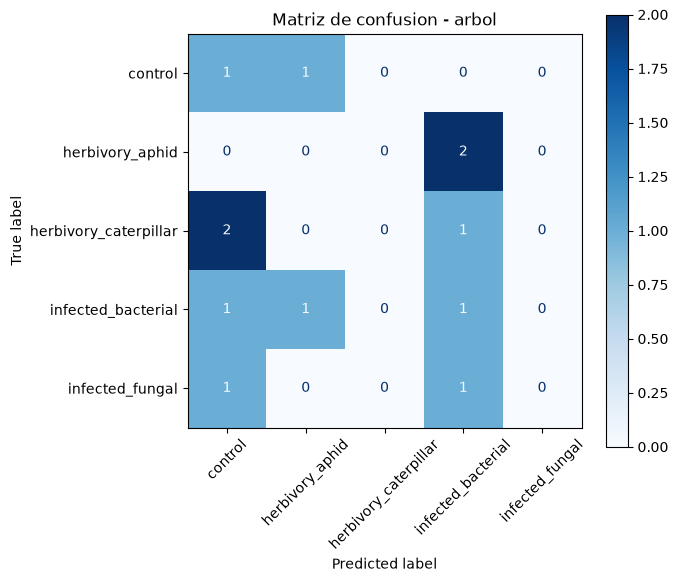

In [48]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(
    base_classifier_moreira, X_test, y_test,
    xticks_rotation=45,
    ax=ax, cmap="Blues"
)
plt.title("Matriz de confusion - arbol")
plt.tight_layout()
plt.show()

In [49]:
print("Distribucion de las predicciones:")
print(pd.Series(y_pred_base_moreira).value_counts())

Distribucion de las predicciones:
infected_bacterial    5
control               5
herbivory_aphid       2
Name: count, dtype: int64


In [50]:


base_classifier_moreira_v2 = DecisionTreeClassifier(min_samples_split=5, criterion="gini", max_depth=10, random_state=123)
base_classifier_moreira_v2.fit(X_train, y_train)
y_pred_v2 = base_classifier_moreira_v2.predict(X_test)

print(f"Precision con mayor profundidad: {accuracy_score(y_test, y_pred_v2)}")
print(f"\n{classification_report(y_test, y_pred_v2, zero_division=0)}")

print("\nDistribucion de predicciones:")
print(pd.Series(y_pred_v2).value_counts())

Precision con mayor profundidad: 0.3333333333333333

                       precision    recall  f1-score   support

              control       0.33      0.50      0.40         2
      herbivory_aphid       0.00      0.00      0.00         2
herbivory_caterpillar       1.00      0.33      0.50         3
   infected_bacterial       0.33      0.67      0.44         3
      infected_fungal       0.00      0.00      0.00         2

             accuracy                           0.33        12
            macro avg       0.33      0.30      0.27        12
         weighted avg       0.39      0.33      0.30        12


Distribucion de predicciones:
infected_bacterial       6
control                  3
herbivory_aphid          2
herbivory_caterpillar    1
Name: count, dtype: int64


## Random Forest

In [51]:
grid_search_RF_moreira = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=123),
    param_grid=params_rf,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_RF_moreira.fit(X_train, y_train)

print(f"Mejores parametros: {grid_search_RF_moreira.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_RF_moreira.best_score_}")

C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Mejores parametros: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 20, 'n_estimators': 100}
Mejor f1_macro en CV: 0.2572063492063492


C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


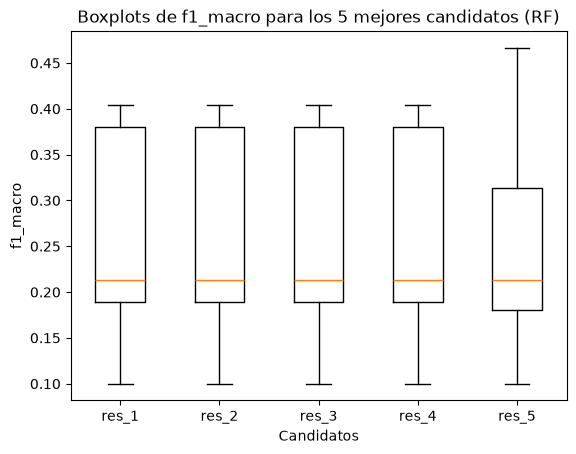

Parametros de cada uno:
res_1m: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 20, 'n_estimators': 100}
res_2m: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 20, 'n_estimators': 100}
res_3m: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 20, 'n_estimators': 100}
res_4m: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 20, 'n_estimators': 100}
res_5m: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}


In [52]:
#Top 5
resultados_cv_rf_moreira = pd.DataFrame(grid_search_RF_moreira.cv_results_)
sorted_results_rf_moreira = resultados_cv_rf_moreira.sort_values(by="mean_test_f1_macro", ascending=False).head(5)

res_1m = sorted_results_rf_moreira[cols_folds].iloc[0]
res_2m = sorted_results_rf_moreira[cols_folds].iloc[1]
res_3m = sorted_results_rf_moreira[cols_folds].iloc[2]
res_4m = sorted_results_rf_moreira[cols_folds].iloc[3]
res_5m = sorted_results_rf_moreira[cols_folds].iloc[4]

plt.boxplot([res_1m.values, res_2m.values, res_3m.values, res_4m.values, res_5m.values],
            tick_labels=["res_1","res_2","res_3","res_4","res_5"])
plt.title("Boxplots de f1_macro para los 5 mejores candidatos (RF)")
plt.xlabel("Candidatos")
plt.ylabel("f1_macro")
plt.show()

print("Parametros de cada uno:")
for i in range(5):
    print(f"res_{i+1}m: {sorted_results_rf_moreira['params'].iloc[i]}")

Elijo res_5m. Misma mediana que res_1 a res_4, pero con mejor techo y menos dispersión entre folds

In [53]:
#Entrenar el modelo con los parámetros elegidos
mejores_params_RF_moreira = sorted_results_rf_moreira["params"].iloc[4]
print(f"Parametros elegidos: {mejores_params_RF_moreira}")

best_model_RF_moreira = RandomForestClassifier(**mejores_params_RF_moreira, class_weight="balanced", random_state=123)
best_model_RF_moreira.fit(X_train, y_train)

y_train_pred_rf_moreira = best_model_RF_moreira.predict(X_train)
y_test_pred_rf_moreira = best_model_RF_moreira.predict(X_test)

print(f"\nF1 macro en train: {f1_score(y_train, y_train_pred_rf_moreira, average='macro')}")
print(f"F1 macro en test: {f1_score(y_test, y_test_pred_rf_moreira, average='macro')}")

print(f"\n{classification_report(y_test, y_test_pred_rf_moreira, zero_division=0)}")

Parametros elegidos: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}

F1 macro en train: 0.9787114845938376
F1 macro en test: 0.27999999999999997

                       precision    recall  f1-score   support

              control       0.33      0.50      0.40         2
      herbivory_aphid       0.00      0.00      0.00         2
herbivory_caterpillar       0.67      0.67      0.67         3
   infected_bacterial       0.33      0.33      0.33         3
      infected_fungal       0.00      0.00      0.00         2

             accuracy                           0.33        12
            macro avg       0.27      0.30      0.28        12
         weighted avg       0.31      0.33      0.32        12



# XGBoost

In [54]:
y_train_enc_moreira = le.fit_transform(y_train)
y_test_enc_moreira = le.transform(y_test)

xgb_classifier_moreira = XGBClassifier(
    booster="gbtree", n_estimators=200,
    eta=0.1, gamma=1, max_depth=15,
    tree_method="hist", random_state=123
)
xgb_classifier_moreira.fit(X_train, y_train_enc_moreira)
y_pred_base_xgb_moreira = xgb_classifier_moreira.predict(X_test)

print(f"Precision de XGBoost base: {accuracy_score(y_test_enc_moreira, y_pred_base_xgb_moreira)}")
print(f"\n{classification_report(y_test_enc_moreira, y_pred_base_xgb_moreira, target_names=le.classes_, zero_division=0)}")

Precision de XGBoost base: 0.3333333333333333

                       precision    recall  f1-score   support

              control       0.25      0.50      0.33         2
      herbivory_aphid       0.00      0.00      0.00         2
herbivory_caterpillar       0.50      0.67      0.57         3
   infected_bacterial       0.50      0.33      0.40         3
      infected_fungal       0.00      0.00      0.00         2

             accuracy                           0.33        12
            macro avg       0.25      0.30      0.26        12
         weighted avg       0.29      0.33      0.30        12



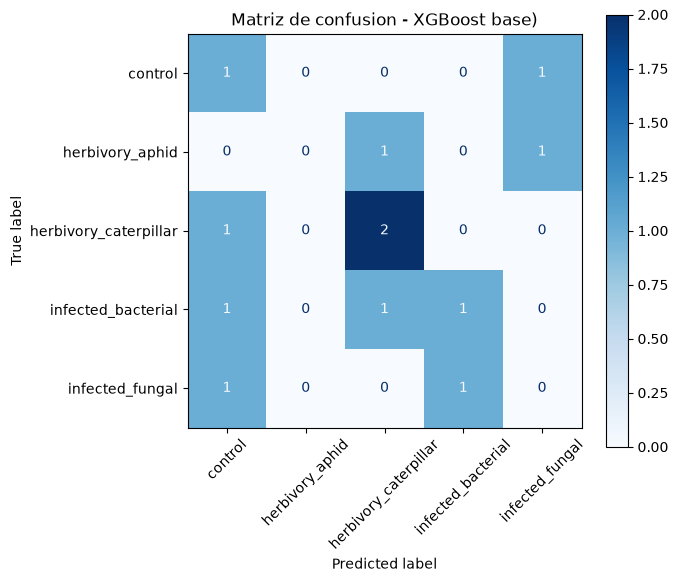

In [55]:
#MC
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(
    xgb_classifier_moreira, X_test, y_test_enc_moreira,
    display_labels=le.classes_,
    xticks_rotation=45,
    ax=ax, cmap="Blues"
)
plt.title("Matriz de confusion - XGBoost base)")
plt.tight_layout()
plt.show()


In [56]:
importancias_moreira = pd.Series(
    xgb_classifier_moreira.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

print("Importancia de features (XGBoost):")
print(importancias_moreira)

print(f"\nFeatures con importancia > 0: {(importancias_moreira > 0).sum()} de {len(importancias_moreira)}")

Importancia de features (XGBoost):
12391      0.101790
12388      0.089134
5281516    0.079110
19800      0.074582
9862       0.068462
19773      0.066623
22311      0.066411
5363374    0.065167
6549       0.059656
240        0.059638
10407      0.059071
6429302    0.054645
12389      0.054607
8175       0.051133
31289      0.049970
dtype: float32

Features con importancia > 0: 15 de 15


In [57]:
grid_search_XGB_moreira = GridSearchCV(
    estimator=XGBClassifier(booster="gbtree", tree_method="hist", random_state=123),
    param_grid=params_xgb,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_XGB_moreira.fit(X_train, y_train_enc_moreira)

print(f"Mejores parametros: {grid_search_XGB_moreira.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_XGB_moreira.best_score_}")

C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Mejores parametros: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 2, 'n_estimators': 150}
Mejor f1_macro en CV: 0.28800000000000003


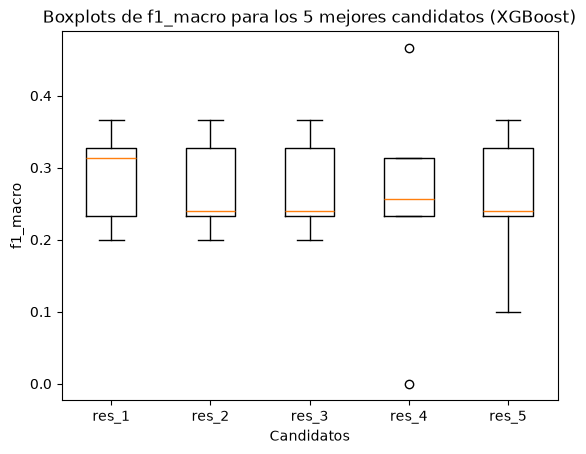

Parametros de cada uno:
res_1xm: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 2, 'n_estimators': 150}
res_2xm: {'eta': 0.1, 'gamma': 0.1, 'max_depth': 2, 'n_estimators': 100}
res_3xm: {'eta': 0.1, 'gamma': 0.1, 'max_depth': 2, 'n_estimators': 150}
res_4xm: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 3, 'n_estimators': 150}
res_5xm: {'eta': 0.2, 'gamma': 0.1, 'max_depth': 2, 'n_estimators': 150}


In [58]:
# Top5
resultados_cv_xgb_moreira = pd.DataFrame(grid_search_XGB_moreira.cv_results_)
sorted_results_xgb_moreira = resultados_cv_xgb_moreira.sort_values(by="mean_test_f1_macro", ascending=False).head(5)

res_1xm = sorted_results_xgb_moreira[cols_folds].iloc[0]
res_2xm = sorted_results_xgb_moreira[cols_folds].iloc[1]
res_3xm = sorted_results_xgb_moreira[cols_folds].iloc[2]
res_4xm = sorted_results_xgb_moreira[cols_folds].iloc[3]
res_5xm = sorted_results_xgb_moreira[cols_folds].iloc[4]

plt.boxplot([res_1xm.values, res_2xm.values, res_3xm.values, res_4xm.values, res_5xm.values],
            tick_labels=["res_1","res_2","res_3","res_4","res_5"])
plt.title("Boxplots de f1_macro para los 5 mejores candidatos (XGBoost)")
plt.xlabel("Candidatos")
plt.ylabel("f1_macro")
plt.show()

print("Parametros de cada uno:")
for i in range(5):
    print(f"res_{i+1}xm: {sorted_results_xgb_moreira['params'].iloc[i]}")

res_1xm se destaca por tener una mediana mas alta, mínimo más alto y una caja angosta.

In [59]:
#Entrenar el modelo con los parámetros elegidos
mejores_params_XGB_moreira = sorted_results_xgb_moreira["params"].iloc[0]
best_model_XGB_moreira = XGBClassifier(**mejores_params_XGB_moreira, booster="gbtree", tree_method="hist", random_state=123)
best_model_XGB_moreira.fit(X_train, y_train_enc_moreira)

y_train_pred_xgb_moreira = best_model_XGB_moreira.predict(X_train)
y_test_pred_xgb_moreira = best_model_XGB_moreira.predict(X_test)

print(f"F1 macro en train: {f1_score(y_train_enc_moreira, y_train_pred_xgb_moreira, average='macro')}")
print(f"F1 macro en test: {f1_score(y_test_enc_moreira, y_test_pred_xgb_moreira, average='macro')}")

print(f"\n{classification_report(y_test_enc_moreira, y_test_pred_xgb_moreira, target_names=le.classes_, zero_division=0)}")

F1 macro en train: 1.0
F1 macro en test: 0.26095238095238094

                       precision    recall  f1-score   support

              control       0.25      0.50      0.33         2
      herbivory_aphid       0.00      0.00      0.00         2
herbivory_caterpillar       0.50      0.67      0.57         3
   infected_bacterial       0.50      0.33      0.40         3
      infected_fungal       0.00      0.00      0.00         2

             accuracy                           0.33        12
            macro avg       0.25      0.30      0.26        12
         weighted avg       0.29      0.33      0.30        12



In [60]:
# Tabla resumen
resumen_modelos_moreira = pd.DataFrame([
    {
        "modelo": "Arbol de decision (max_depth=10)",
        "f1_macro_train": f1_score(y_train, base_classifier_moreira_v2.predict(X_train), average="macro"),
        "f1_macro_test": f1_score(y_test, y_pred_v2, average="macro"),
        "accuracy_test": accuracy_score(y_test, y_pred_v2),
    },
    {
        "modelo": "Random Forest (tuneado)",
        "f1_macro_train": f1_score(y_train, y_train_pred_rf_moreira, average="macro"),
        "f1_macro_test": f1_score(y_test, y_test_pred_rf_moreira, average="macro"),
        "accuracy_test": accuracy_score(y_test, y_test_pred_rf_moreira),
    },
    {
        "modelo": "XGBoost (tuneado)",
        "f1_macro_train": f1_score(y_train_enc_moreira, y_train_pred_xgb_moreira, average="macro"),
        "f1_macro_test": f1_score(y_test_enc_moreira, y_test_pred_xgb_moreira, average="macro"),
        "accuracy_test": accuracy_score(y_test_enc_moreira, y_test_pred_xgb_moreira),
    },
])

resumen_modelos_moreira["gap_sobreajuste"] = resumen_modelos_moreira["f1_macro_train"] - resumen_modelos_moreira["f1_macro_test"]
print(resumen_modelos_moreira.round(3).to_string(index=False))

                          modelo  f1_macro_train  f1_macro_test  accuracy_test  gap_sobreajuste
Arbol de decision (max_depth=10)           0.862          0.269          0.333            0.593
         Random Forest (tuneado)           0.979          0.280          0.333            0.699
               XGBoost (tuneado)           1.000          0.261          0.333            0.739


Se selecciona el árbol de decisión como modelo, no por superioridad de rendimiento ya que todos resultaron prácticamente equivalentes. El techo de rendimiento en este dataset está determinado por el tamaño de muestra disponible y no por la capacidad del algoritmo elegido, una limitación que ningún modelo, por más sofisticado que sea, puede compensar con los datos actuales. 

## SHAP

In [61]:
explainer_moreira = shap.TreeExplainer(base_classifier_moreira_v2)
shap_values_moreira = explainer_moreira.shap_values(X_test)

print(f"Forma de shap_values: {np.array(shap_values_moreira).shape}")

Forma de shap_values: (12, 15, 5)


In [62]:
shap_values_array_moreira = np.array(shap_values_moreira) 

# Mirar solo las clases que mostraron señal en los 3 modelos

clases_con_senal = ["control", "herbivory_caterpillar", "infected_bacterial"]

for clase in clases_con_senal:
    idx_clase = list(le.classes_).index(clase)
    shap_clase = shap_values_array_moreira[:, :, idx_clase]
    importancia_clase = pd.Series(
        np.abs(shap_clase).mean(axis=0), index=X_test.columns
    ).sort_values(ascending=False)

    print(f"\n=== Top 5 compuestos para '{clase}' ===")
    print(importancia_clase.head(5))


=== Top 5 compuestos para 'control' ===
9862     0.234261
10407    0.121681
12388    0.086138
31289    0.038179
19800    0.018456
dtype: float64

=== Top 5 compuestos para 'herbivory_caterpillar' ===
9862       0.141055
6429302    0.105938
31289      0.077595
19800      0.076843
12388      0.068002
dtype: float64

=== Top 5 compuestos para 'infected_bacterial' ===
6429302    0.177889
9862       0.102013
10407      0.101571
12388      0.091531
6549       0.065115
dtype: float64


In [63]:
top_cids_moreira = [9862, 10407, 12388, 31289, 19800, 6429302, 6549]
nombres_moreira = compuestos[compuestos["pubchem_cid"].isin(top_cids_moreira)][
    ["pubchem_cid", "name_original"]
].drop_duplicates(subset=["pubchem_cid"])
print(nombres_moreira.to_string(index=False))

 pubchem_cid             name_original
      9862.0 5-Hepten-2-one, 6-methyl-
   6429302.0       trans-a-bergamotene
      6549.0                  Linalool
     31289.0                   Nonanal
     10407.0           (E)-b-farnesene
     19800.0         2-butyl-1-octanol
     12388.0                 Tridecane


In [64]:
export_classifier(
    "moreira2024",
    model=base_classifier_moreira_v2,
    feature_columns=X_train.columns,
    meta={"especie": "Brassica rapa", "modelo": "Arbol de decision", "f1_macro_test": 0.27}
)

Exportado clasificador: moreira2024 -> ..\models\moreira2024


# Ayelo2026

### Carga de datos

In [65]:
muestras = muestras_todas[muestras_todas["dataset_origin"] == "Ayelo2026"].copy()
compuestos = compuestos_todos[compuestos_todos["dataset_origin"] == "Ayelo2026"].copy()
abundancias = pd.read_parquet("../db/data/processed/abundancias_ayelo2026.parquet")

print(f"muestras: {muestras.shape}")
print(f"compuestos: {compuestos.shape}")
print(f"abundancias: {abundancias.shape}")

print(f"\nFrecuencia de cada estado fisiologico: \n{muestras['physiological_state'].value_counts()}")

# Chequear de contaminantes  
posibles_contaminantes = compuestos[
    compuestos["name_original"].str.contains(
        "phthalate|siloxane|silane|BHT|butylated hydroxytoluene",
        case=False, na=False
    )
]
print(f"\nPosibles contaminantes: {len(posibles_contaminantes)}")

muestras: (60, 19)
compuestos: (13, 15)
abundancias: (780, 4)

Frecuencia de cada estado fisiologico: 
physiological_state
herbivory_exposed    50
control              10
Name: count, dtype: int64

Posibles contaminantes: 0


### Matriz de features

In [66]:
abundancias_cid = abundancias.merge(
    compuestos[["compuesto_id", "pubchem_cid"]],
    on="compuesto_id",
    how="left"
)

print(f"Filas de abundancia sin cid: {abundancias_cid['pubchem_cid'].isna().sum()} de {len(abundancias_cid)}")

abundancias_cid = abundancias_cid.dropna(subset=["pubchem_cid"])
abundancias_cid["pubchem_cid"] = abundancias_cid["pubchem_cid"].astype(int)

matriz_features = abundancias_cid.pivot_table(
    index="sample_id",
    columns="pubchem_cid",
    values="abundancia",
    aggfunc="mean"
)

print(f"\nmatriz_features: {matriz_features.shape}")
print(f"Total de NaN: {matriz_features.isna().sum().sum()}")

Filas de abundancia sin cid: 0 de 780

matriz_features: (60, 13)
Total de NaN: 0


### Estandarización


In [67]:
matriz_zscore = matriz_features.apply(zscore)
print(f"NaN despues del z-score: {matriz_zscore.isna().sum().sum()}")

datos_modelo = muestras.set_index("sample_id")[["physiological_state"]].join(matriz_zscore)

X = datos_modelo.drop("physiological_state", axis=1)
X.columns = X.columns.astype(str)
y = datos_modelo["physiological_state"]

print(f"\nX: {X.shape}")

NaN despues del z-score: 0

X: (60, 13)


### X e Y + Tr/Ts

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=123
)

print(f"Frecuencia en tr: \n{y_train.value_counts()}")
print(f"\nFrecuencia en ts: \n{y_test.value_counts()}")

Frecuencia en tr: 
physiological_state
herbivory_exposed    40
control               8
Name: count, dtype: int64

Frecuencia en ts: 
physiological_state
herbivory_exposed    10
control               2
Name: count, dtype: int64


## Árbol de decisión

In [69]:
base_classifier_ayelo = DecisionTreeClassifier(min_samples_split=10, criterion="gini", max_depth=5, random_state=123)
base_classifier_ayelo.fit(X_train, y_train)
y_pred_base_ayelo = base_classifier_ayelo.predict(X_test)

print(f"Precision del arbol estandar: {accuracy_score(y_test, y_pred_base_ayelo)}")
print(f"\n{classification_report(y_test, y_pred_base_ayelo, zero_division=0)}")

Precision del arbol estandar: 0.8333333333333334

                   precision    recall  f1-score   support

          control       0.50      1.00      0.67         2
herbivory_exposed       1.00      0.80      0.89        10

         accuracy                           0.83        12
        macro avg       0.75      0.90      0.78        12
     weighted avg       0.92      0.83      0.85        12



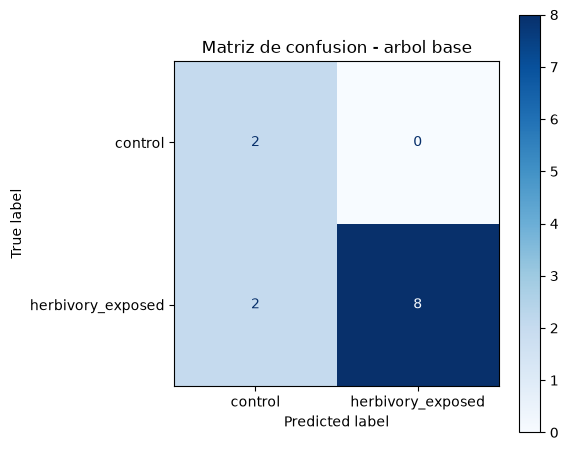

In [70]:
#MC
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    base_classifier_ayelo, X_test, y_test,
    ax=ax, cmap="Blues"
)
plt.title("Matriz de confusion - arbol base")
plt.tight_layout()
plt.show()

## Random Forest

In [71]:
grid_search_RF_ayelo = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=123),
    param_grid=params_rf,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_RF_ayelo.fit(X_train, y_train)

print(f"Mejores parametros: {grid_search_RF_ayelo.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_RF_ayelo.best_score_}")

C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Mejores parametros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 150}
Mejor f1_macro en CV: 0.8222222222222222


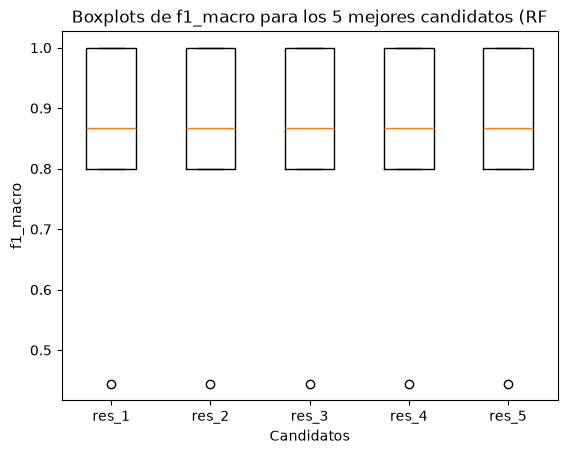

Parametros de cada uno:
res_1a: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}
res_2a: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 150}
res_3a: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}
res_4a: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 150}
res_5a: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}


In [72]:
# Top 5
resultados_cv_rf_ayelo = pd.DataFrame(grid_search_RF_ayelo.cv_results_)
sorted_results_rf_ayelo = resultados_cv_rf_ayelo.sort_values(by="mean_test_f1_macro", ascending=False).head(5)

res_1a = sorted_results_rf_ayelo[cols_folds].iloc[0]
res_2a = sorted_results_rf_ayelo[cols_folds].iloc[1]
res_3a = sorted_results_rf_ayelo[cols_folds].iloc[2]
res_4a = sorted_results_rf_ayelo[cols_folds].iloc[3]
res_5a = sorted_results_rf_ayelo[cols_folds].iloc[4]

plt.boxplot([res_1a.values, res_2a.values, res_3a.values, res_4a.values, res_5a.values],
            tick_labels=["res_1","res_2","res_3","res_4","res_5"])
plt.title("Boxplots de f1_macro para los 5 mejores candidatos (RF")
plt.xlabel("Candidatos")
plt.ylabel("f1_macro")
plt.show()

print("Parametros de cada uno:")
for i in range(5):
    print(f"res_{i+1}a: {sorted_results_rf_ayelo['params'].iloc[i]}")

Debido a que son todos iguales, selecciono res_1a

In [73]:
# Entrenar el  modelo con el candidato seleccionado
mejores_params_RF_ayelo = sorted_results_rf_ayelo["params"].iloc[0]
best_model_RF_ayelo = RandomForestClassifier(**mejores_params_RF_ayelo, class_weight="balanced", random_state=123)
best_model_RF_ayelo.fit(X_train, y_train)

y_train_pred_rf_ayelo = best_model_RF_ayelo.predict(X_train)
y_test_pred_rf_ayelo = best_model_RF_ayelo.predict(X_test)

print(f"F1 macro en train: {f1_score(y_train, y_train_pred_rf_ayelo, average='macro')}")
print(f"F1 macro en test: {f1_score(y_test, y_test_pred_rf_ayelo, average='macro')}")

print(f"\n{classification_report(y_test, y_test_pred_rf_ayelo, zero_division=0)}")

F1 macro en train: 0.9642591213700671
F1 macro en test: 0.8736842105263158

                   precision    recall  f1-score   support

          control       0.67      1.00      0.80         2
herbivory_exposed       1.00      0.90      0.95        10

         accuracy                           0.92        12
        macro avg       0.83      0.95      0.87        12
     weighted avg       0.94      0.92      0.92        12



## XGBoost

In [74]:
y_train_enc_ayelo = le.fit_transform(y_train)
y_test_enc_ayelo = le.transform(y_test)

xgb_classifier_ayelo = XGBClassifier(
    booster="gbtree", n_estimators=200,
    eta=0.1, gamma=1, max_depth=15,
    tree_method="hist", random_state=123
)
xgb_classifier_ayelo.fit(X_train, y_train_enc_ayelo)
y_pred_base_xgb_ayelo = xgb_classifier_ayelo.predict(X_test)

print(f"Precision de XGBoost base: {accuracy_score(y_test_enc_ayelo, y_pred_base_xgb_ayelo)}")
print(f"\n{classification_report(y_test_enc_ayelo, y_pred_base_xgb_ayelo, target_names=le.classes_, zero_division=0)}")

Precision de XGBoost base: 0.75

                   precision    recall  f1-score   support

          control       0.33      0.50      0.40         2
herbivory_exposed       0.89      0.80      0.84        10

         accuracy                           0.75        12
        macro avg       0.61      0.65      0.62        12
     weighted avg       0.80      0.75      0.77        12



In [75]:
grid_search_XGB_ayelo = GridSearchCV(
    estimator=XGBClassifier(booster="gbtree", tree_method="hist", random_state=123),
    param_grid=params_xgb,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_XGB_ayelo.fit(X_train, y_train_enc_ayelo)

print(f"Mejores parametros: {grid_search_XGB_ayelo.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_XGB_ayelo.best_score_}")


C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Mejores parametros: {'eta': 0.2, 'gamma': 0.1, 'max_depth': 2, 'n_estimators': 50}
Mejor f1_macro en CV: 0.7037908496732026


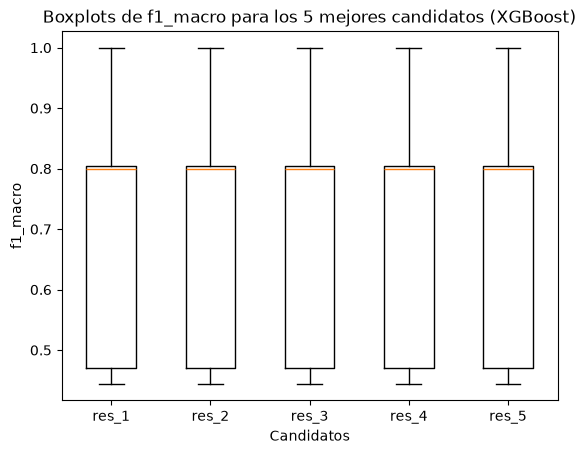

Parametros de cada uno:
res_1xa: {'eta': 0.2, 'gamma': 0.1, 'max_depth': 3, 'n_estimators': 50}
res_2xa: {'eta': 0.2, 'gamma': 0.1, 'max_depth': 5, 'n_estimators': 150}
res_3xa: {'eta': 0.2, 'gamma': 0.1, 'max_depth': 2, 'n_estimators': 150}
res_4xa: {'eta': 0.2, 'gamma': 0.1, 'max_depth': 2, 'n_estimators': 50}
res_5xa: {'eta': 0.2, 'gamma': 0.1, 'max_depth': 5, 'n_estimators': 100}


In [76]:
#Top5
resultados_cv_xgb_ayelo = pd.DataFrame(grid_search_XGB_ayelo.cv_results_)
sorted_results_xgb_ayelo = resultados_cv_xgb_ayelo.sort_values(by="mean_test_f1_macro", ascending=False).head(5)

res_1xa = sorted_results_xgb_ayelo[cols_folds].iloc[0]
res_2xa = sorted_results_xgb_ayelo[cols_folds].iloc[1]
res_3xa = sorted_results_xgb_ayelo[cols_folds].iloc[2]
res_4xa = sorted_results_xgb_ayelo[cols_folds].iloc[3]
res_5xa = sorted_results_xgb_ayelo[cols_folds].iloc[4]

plt.boxplot([res_1xa.values, res_2xa.values, res_3xa.values, res_4xa.values, res_5xa.values],
            tick_labels=["res_1","res_2","res_3","res_4","res_5"])
plt.title("Boxplots de f1_macro para los 5 mejores candidatos (XGBoost)")
plt.xlabel("Candidatos")
plt.ylabel("f1_macro")
plt.show()

print("Parametros de cada uno:")
for i in range(5):
    print(f"res_{i+1}xa: {sorted_results_xgb_ayelo['params'].iloc[i]}")

Los 5 Son idénticos, entrenos el modelo con res_1xa

In [77]:
# Entrenar modelo con candidato seleccionado
mejores_params_XGB_ayelo = sorted_results_xgb_ayelo["params"].iloc[0]
best_model_XGB_ayelo = XGBClassifier(**mejores_params_XGB_ayelo, booster="gbtree", tree_method="hist", random_state=123)
best_model_XGB_ayelo.fit(X_train, y_train_enc_ayelo)

y_train_pred_xgb_ayelo = best_model_XGB_ayelo.predict(X_train)
y_test_pred_xgb_ayelo = best_model_XGB_ayelo.predict(X_test)

print(f"F1 macro en tr: {f1_score(y_train_enc_ayelo, y_train_pred_xgb_ayelo, average='macro')}")
print(f"F1 macro en ts: {f1_score(y_test_enc_ayelo, y_test_pred_xgb_ayelo, average='macro')}")

print(f"\n{classification_report(y_test_enc_ayelo, y_test_pred_xgb_ayelo, target_names=le.classes_, zero_division=0)}")

F1 macro en tr: 1.0
F1 macro en ts: 0.6210526315789473

                   precision    recall  f1-score   support

          control       0.33      0.50      0.40         2
herbivory_exposed       0.89      0.80      0.84        10

         accuracy                           0.75        12
        macro avg       0.61      0.65      0.62        12
     weighted avg       0.80      0.75      0.77        12



In [78]:
# Tabla resumen
resumen_modelos_ayelo = pd.DataFrame([
    {
        "modelo": "Arbol de decision (base)",
        "f1_macro_train": f1_score(y_train, base_classifier_ayelo.predict(X_train), average="macro"),
        "f1_macro_test": f1_score(y_test, y_pred_base_ayelo, average="macro"),
        "accuracy_test": accuracy_score(y_test, y_pred_base_ayelo),
    },
    {
        "modelo": "Random Forest (tuneado)",
        "f1_macro_train": f1_score(y_train, y_train_pred_rf_ayelo, average="macro"),
        "f1_macro_test": f1_score(y_test, y_test_pred_rf_ayelo, average="macro"),
        "accuracy_test": accuracy_score(y_test, y_test_pred_rf_ayelo),
    },
    {
        "modelo": "XGBoost (tuneado)",
        "f1_macro_train": f1_score(y_train_enc_ayelo, y_train_pred_xgb_ayelo, average="macro"),
        "f1_macro_test": f1_score(y_test_enc_ayelo, y_test_pred_xgb_ayelo, average="macro"),
        "accuracy_test": accuracy_score(y_test_enc_ayelo, y_test_pred_xgb_ayelo),
    },
])

resumen_modelos_ayelo["gap_sobreajuste"] = resumen_modelos_ayelo["f1_macro_train"] - resumen_modelos_ayelo["f1_macro_test"]
print(resumen_modelos_ayelo.round(3).to_string(index=False))

                  modelo  f1_macro_train  f1_macro_test  accuracy_test  gap_sobreajuste
Arbol de decision (base)           0.964          0.778          0.833            0.186
 Random Forest (tuneado)           0.964          0.874          0.917            0.091
       XGBoost (tuneado)           1.000          0.621          0.750            0.379


Se selecciona Random Forest como modelo final, superando claramente tanto al árbol de decisión simple como a XGBoost tuneado. 

## SHAP

In [79]:
explainer_ayelo = shap.TreeExplainer(best_model_RF_ayelo)
shap_values_ayelo = explainer_ayelo.shap_values(X_test)

print(f"Forma de shap_values: {np.array(shap_values_ayelo).shape}")

Forma de shap_values: (12, 13, 2)


In [80]:
shap_values_array_ayelo = np.array(shap_values_ayelo)
shap_herbivory = shap_values_array_ayelo[:, :, 1] 

importancia_ayelo = pd.Series(
    np.abs(shap_herbivory).mean(axis=0), index=X_test.columns
).sort_values(ascending=False)

print("Top 10 compuestos mas importantes para distinguir herbivory/control:")
print(importancia_ayelo.head(10))

top_cids_ayelo = [int(c) for c in importancia_ayelo.head(10).index]
nombres_ayelo = compuestos[compuestos["pubchem_cid"].isin(top_cids_ayelo)][
    ["pubchem_cid", "name_original"]
].drop_duplicates(subset=["pubchem_cid"])
print("\nNombres:")
print(nombres_ayelo.to_string(index=False))

Top 10 compuestos mas importantes para distinguir herbivory/control:
5363388    0.168966
240        0.104501
6654       0.070542
6427110    0.051144
440917     0.022523
31289      0.019634
18756      0.015653
14896      0.012413
5281520    0.009992
8175       0.009484
dtype: float64

Nombres:
 pubchem_cid                        name_original
      6654.0                         alpha-Pinene
       240.0                         Benzaldehyde
     14896.0                          beta-Pinene
   5363388.0                (Z)-3-Hexenyl acetate
    440917.0                           D-Limonene
     18756.0                         beta-Ocimene
     31289.0                              Nonanal
   6427110.0 DMNT (4,8-dimethylnona-1,3,7-triene)
      8175.0                              Decanal
   5281520.0                       alpha-Humulene


In [81]:
export_classifier(
    "ayelo2026",
    model=best_model_RF_ayelo,
    feature_columns=X_train.columns,
    meta={"especie": "Gossypium hirsutum", "modelo": "Random Forest", "f1_macro_test": 0.87}
)

Exportado clasificador: ayelo2026 -> ..\models\ayelo2026


# GHOSH2022

### Carga de datos

In [82]:
muestras = muestras_todas[muestras_todas["dataset_origin"] == "Ghosh2022"].copy()
compuestos = compuestos_todos[compuestos_todos["dataset_origin"] == "Ghosh2022"].copy()
abundancias = pd.read_parquet("../db/data/processed/abundancias_ghosh2022.parquet")

print(f"muestras: {muestras.shape}")
print(f"compuestos: {compuestos.shape}")
print(f"abundancias: {abundancias.shape}")

print(f"\nFrecuencia de cada estado fisiologico: \n{muestras['physiological_state'].value_counts()}")
print(f"\nFrecuencia de cada especie: \n{muestras['species'].value_counts()}")

# Chequear contaminantes 
posibles_contaminantes = compuestos[
    compuestos["name_original"].str.contains(
        "phthalate|siloxane|silane|BHT|butylated hydroxytoluene",
        case=False, na=False
    )
]
print(f"\nPosibles contaminantes: {len(posibles_contaminantes)}")
if len(posibles_contaminantes) > 0:
    print(posibles_contaminantes[["pubchem_cid", "name_original"]].to_string(index=False))

muestras: (29, 19)
compuestos: (169, 15)
abundancias: (2442, 4)

Frecuencia de cada estado fisiologico: 
physiological_state
control           10
herbivory_only    10
infected_viral     9
Name: count, dtype: int64

Frecuencia de cada especie: 
species
Solanum lycopersicum    15
Capsicum annuum         14
Name: count, dtype: int64

Posibles contaminantes: 0


### Matriz de features

In [83]:
abundancias_cid = abundancias.merge(
    compuestos[["compuesto_id", "pubchem_cid"]],
    on="compuesto_id",
    how="left"
)

print(f"Filas de abundancia sin  cid: {abundancias_cid['pubchem_cid'].isna().sum()} de {len(abundancias_cid)}")

abundancias_cid = abundancias_cid.dropna(subset=["pubchem_cid"])
abundancias_cid["pubchem_cid"] = abundancias_cid["pubchem_cid"].astype(int)

matriz_features = abundancias_cid.pivot_table(
    index="sample_id",
    columns="pubchem_cid",
    values="abundancia",
    aggfunc="mean"
)

print(f"\nmatriz_features: {matriz_features.shape}")
print(f"Total de NaN: {matriz_features.isna().sum().sum()}")
print(f"Proporcion de NaN: {matriz_features.isna().mean().mean():.2%}")

Filas de abundancia sin  cid: 0 de 2442

matriz_features: (29, 137)
Total de NaN: 1574
Proporcion de NaN: 39.62%


In [84]:
# Verificar si el missing esta estructurado por especie 
cobertura_por_especie = abundancias_cid.merge(
    muestras[["sample_id", "species"]], on="sample_id"
).groupby(["pubchem_cid", "species"]).size().unstack(fill_value=0)

# Contar cuantos CID estan solo en tomate, solo en pimiento, o en ambos
solo_tomate = ((cobertura_por_especie.get("Solanum lycopersicum", 0) > 0) &
               (cobertura_por_especie.get("Capsicum annuum", 0) == 0)).sum()
solo_pimiento = ((cobertura_por_especie.get("Capsicum annuum", 0) > 0) &
                  (cobertura_por_especie.get("Solanum lycopersicum", 0) == 0)).sum()
ambas = ((cobertura_por_especie.get("Solanum lycopersicum", 0) > 0) &
         (cobertura_por_especie.get("Capsicum annuum", 0) > 0)).sum()

print(f"CID en tomate: {solo_tomate}")
print(f"CID en pimiento: {solo_pimiento}")
print(f"CID en ambas: {ambas}")

CID en tomate: 47
CID en pimiento: 61
CID en ambas: 29


In [85]:
# Verificat si physiological_state esta parejo entre las 2 especies 
tabla_cruzada = pd.crosstab(muestras["physiological_state"], muestras["species"])
print(tabla_cruzada)

species              Capsicum annuum  Solanum lycopersicum
physiological_state                                       
control                            5                     5
herbivory_only                     5                     5
infected_viral                     4                     5


In [86]:
matriz_features_rf = matriz_features.fillna(0)
matriz_zscore_rf = matriz_features_rf.apply(zscore)

matriz_zscore_xgb = (matriz_features - matriz_features.mean()) / matriz_features.std()

print(f"NaN en matriz_zscore_rf: {matriz_zscore_rf.isna().sum().sum()}")
print(f"NaN en matriz_zscore_xgb: {matriz_zscore_xgb.isna().sum().sum()}")

NaN en matriz_zscore_rf: 0
NaN en matriz_zscore_xgb: 1574


### X e Y + Tr/Ts

In [87]:
datos_modelo_rf = muestras.set_index("sample_id")[["species", "physiological_state"]].join(matriz_zscore_rf)
datos_modelo_rf = pd.get_dummies(datos_modelo_rf, columns=["species"], drop_first=True)
X_rf = datos_modelo_rf.drop("physiological_state", axis=1)
X_rf.columns = X_rf.columns.astype(str)
y_rf = datos_modelo_rf["physiological_state"]

datos_modelo_xgb = muestras.set_index("sample_id")[["species", "physiological_state"]].join(matriz_zscore_xgb)
datos_modelo_xgb = pd.get_dummies(datos_modelo_xgb, columns=["species"], drop_first=True)
X_xgb = datos_modelo_xgb.drop("physiological_state", axis=1)
X_xgb.columns = X_xgb.columns.astype(str)
y_xgb = datos_modelo_xgb["physiological_state"]

print(f"X_rf: {X_rf.shape}, X_xgb: {X_xgb.shape}")

X_rf: (29, 138), X_xgb: (29, 138)


In [88]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, stratify=y_rf, random_state=123
)
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=0.2, stratify=y_xgb, random_state=123
)

print(f"Mismo split: {(y_train_rf.values == y_train_xgb.values).all()}")
print(f"\nFrecuencia en tr: \n{y_train_rf.value_counts()}")
print(f"\nFrecuencia en ts: \n{y_test_rf.value_counts()}")

Mismo split: True

Frecuencia en tr: 
physiological_state
herbivory_only    8
control           8
infected_viral    7
Name: count, dtype: int64

Frecuencia en ts: 
physiological_state
infected_viral    2
control           2
herbivory_only    2
Name: count, dtype: int64


## Árbold e decisión

In [89]:
base_classifier_ghosh = DecisionTreeClassifier(min_samples_split=10, criterion="gini", max_depth=5, random_state=123)
base_classifier_ghosh.fit(X_train_rf, y_train_rf)
y_pred_base_ghosh = base_classifier_ghosh.predict(X_test_rf)

print(f"Precision del arbol estandar: {accuracy_score(y_test_rf, y_pred_base_ghosh)}")
print(f"\n{classification_report(y_test_rf, y_pred_base_ghosh, zero_division=0)}")

Precision del arbol estandar: 0.5

                precision    recall  f1-score   support

       control       0.40      1.00      0.57         2
herbivory_only       0.00      0.00      0.00         2
infected_viral       1.00      0.50      0.67         2

      accuracy                           0.50         6
     macro avg       0.47      0.50      0.41         6
  weighted avg       0.47      0.50      0.41         6



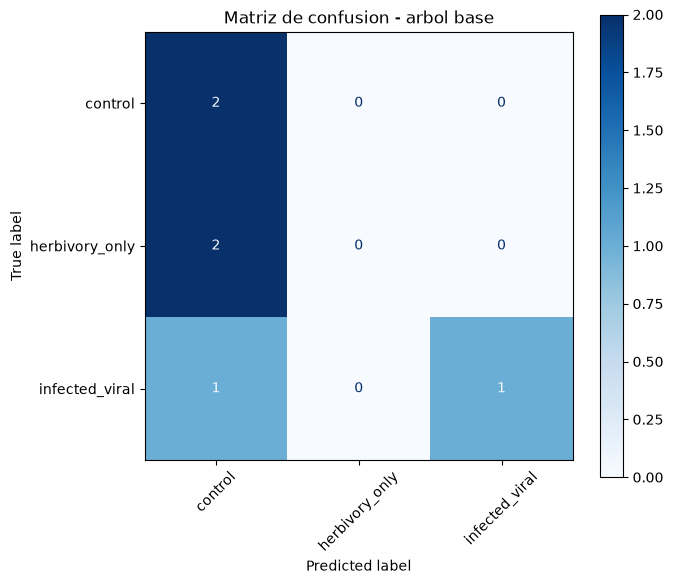

In [90]:
#MC
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(
    base_classifier_ghosh, X_test_rf, y_test_rf,
    xticks_rotation=45,
    ax=ax, cmap="Blues"
)
plt.title("Matriz de confusion - arbol base")
plt.tight_layout()
plt.show()

## Ranodm Forest

In [91]:
grid_search_RF_ghosh = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=123),
    param_grid=params_rf,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_RF_ghosh.fit(X_train_rf, y_train_rf)

print(f"Mejores parametros: {grid_search_RF_ghosh.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_RF_ghosh.best_score_}")

C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Mejores parametros: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
Mejor f1_macro en CV: 0.6422222222222221


C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


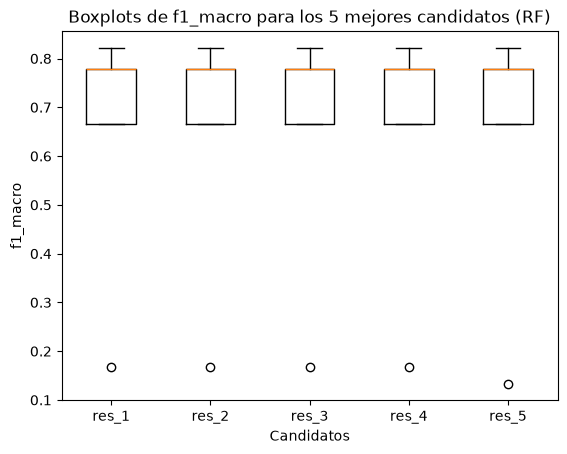

Parametros de cada uno:
res_1g: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
res_2g: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
res_3g: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
res_4g: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 100}
res_5g: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 200}


In [92]:
#Top5
resultados_cv_rf_ghosh = pd.DataFrame(grid_search_RF_ghosh.cv_results_)
sorted_results_rf_ghosh = resultados_cv_rf_ghosh.sort_values(by="mean_test_f1_macro", ascending=False).head(5)

res_1g = sorted_results_rf_ghosh[cols_folds].iloc[0]
res_2g = sorted_results_rf_ghosh[cols_folds].iloc[1]
res_3g = sorted_results_rf_ghosh[cols_folds].iloc[2]
res_4g = sorted_results_rf_ghosh[cols_folds].iloc[3]
res_5g = sorted_results_rf_ghosh[cols_folds].iloc[4]

plt.boxplot([res_1g.values, res_2g.values, res_3g.values, res_4g.values, res_5g.values],
            tick_labels=["res_1","res_2","res_3","res_4","res_5"])
plt.title("Boxplots de f1_macro para los 5 mejores candidatos (RF)")
plt.xlabel("Candidatos")
plt.ylabel("f1_macro")
plt.show()

print("Parametros de cada uno:")
for i in range(5):
    print(f"res_{i+1}g: {sorted_results_rf_ghosh['params'].iloc[i]}")

Debido a que son todos idénticos, selecciono res_1g

In [93]:
# Entrenar al modelo con el candidfato seleccionado
mejores_params_RF_ghosh = sorted_results_rf_ghosh["params"].iloc[0]
best_model_RF_ghosh = RandomForestClassifier(**mejores_params_RF_ghosh, class_weight="balanced", random_state=123)
best_model_RF_ghosh.fit(X_train_rf, y_train_rf)

y_train_pred_rf_ghosh = best_model_RF_ghosh.predict(X_train_rf)
y_test_pred_rf_ghosh = best_model_RF_ghosh.predict(X_test_rf)

print(f"F1 macro en train: {f1_score(y_train_rf, y_train_pred_rf_ghosh, average='macro')}")
print(f"F1 macro en test: {f1_score(y_test_rf, y_test_pred_rf_ghosh, average='macro')}")

print(f"\n{classification_report(y_test_rf, y_test_pred_rf_ghosh, zero_division=0)}")

F1 macro en train: 1.0
F1 macro en test: 0.4000000000000001

                precision    recall  f1-score   support

       control       0.67      1.00      0.80         2
herbivory_only       0.00      0.00      0.00         2
infected_viral       0.33      0.50      0.40         2

      accuracy                           0.50         6
     macro avg       0.33      0.50      0.40         6
  weighted avg       0.33      0.50      0.40         6



## XGBoost

In [94]:
y_train_enc_ghosh = le.fit_transform(y_train_xgb)
y_test_enc_ghosh = le.transform(y_test_xgb)

xgb_classifier_ghosh = XGBClassifier(
    booster="gbtree", n_estimators=200,
    eta=0.1, gamma=1, max_depth=15,
    tree_method="hist", random_state=123
)
xgb_classifier_ghosh.fit(X_train_xgb, y_train_enc_ghosh)
y_pred_base_xgb_ghosh = xgb_classifier_ghosh.predict(X_test_xgb)

print(f"Precision de XGBoost base: {accuracy_score(y_test_enc_ghosh, y_pred_base_xgb_ghosh)}")
print(f"\n{classification_report(y_test_enc_ghosh, y_pred_base_xgb_ghosh, target_names=le.classes_, zero_division=0)}")

Precision de XGBoost base: 0.6666666666666666

                precision    recall  f1-score   support

       control       0.67      1.00      0.80         2
herbivory_only       0.50      0.50      0.50         2
infected_viral       1.00      0.50      0.67         2

      accuracy                           0.67         6
     macro avg       0.72      0.67      0.66         6
  weighted avg       0.72      0.67      0.66         6



In [95]:
grid_search_XGB_ghosh = GridSearchCV(
    estimator=XGBClassifier(booster="gbtree", tree_method="hist", random_state=123),
    param_grid=params_xgb,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_XGB_ghosh.fit(X_train_xgb, y_train_enc_ghosh)

print(f"Mejores parametros: {grid_search_XGB_ghosh.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_XGB_ghosh.best_score_}")

C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Mejores parametros: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 2, 'n_estimators': 150}
Mejor f1_macro en CV: 0.731111111111111


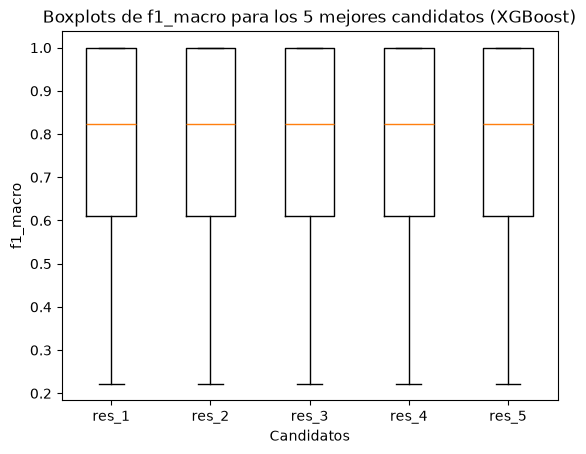

Parametros de cada uno:
res_1xg: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 2, 'n_estimators': 150}
res_2xg: {'eta': 0.05, 'gamma': 0.5, 'max_depth': 5, 'n_estimators': 100}
res_3xg: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 3, 'n_estimators': 150}
res_4xg: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 5, 'n_estimators': 150}
res_5xg: {'eta': 0.05, 'gamma': 0.5, 'max_depth': 5, 'n_estimators': 50}


In [96]:
#Top5
resultados_cv_xgb_ghosh = pd.DataFrame(grid_search_XGB_ghosh.cv_results_)
sorted_results_xgb_ghosh = resultados_cv_xgb_ghosh.sort_values(by="mean_test_f1_macro", ascending=False).head(5)

res_1xg = sorted_results_xgb_ghosh[cols_folds].iloc[0]
res_2xg = sorted_results_xgb_ghosh[cols_folds].iloc[1]
res_3xg = sorted_results_xgb_ghosh[cols_folds].iloc[2]
res_4xg = sorted_results_xgb_ghosh[cols_folds].iloc[3]
res_5xg = sorted_results_xgb_ghosh[cols_folds].iloc[4]

plt.boxplot([res_1xg.values, res_2xg.values, res_3xg.values, res_4xg.values, res_5xg.values],
            tick_labels=["res_1","res_2","res_3","res_4","res_5"])
plt.title("Boxplots de f1_macro para los 5 mejores candidatos (XGBoost)")
plt.xlabel("Candidatos")
plt.ylabel("f1_macro")
plt.show()

print("Parametros de cada uno:")
for i in range(5):
    print(f"res_{i+1}xg: {sorted_results_xgb_ghosh['params'].iloc[i]}")

Debido a que son todos idénticos, selecciono res_1xg

In [97]:
#Entrenar el modelo con el candidato seleccionado 
mejores_params_XGB_ghosh = sorted_results_xgb_ghosh["params"].iloc[0]
best_model_XGB_ghosh = XGBClassifier(**mejores_params_XGB_ghosh, booster="gbtree", tree_method="hist", random_state=123)
best_model_XGB_ghosh.fit(X_train_xgb, y_train_enc_ghosh)

y_train_pred_xgb_ghosh = best_model_XGB_ghosh.predict(X_train_xgb)
y_test_pred_xgb_ghosh = best_model_XGB_ghosh.predict(X_test_xgb)

print(f"F1 macro en train: {f1_score(y_train_enc_ghosh, y_train_pred_xgb_ghosh, average='macro')}")
print(f"F1 macro en test: {f1_score(y_test_enc_ghosh, y_test_pred_xgb_ghosh, average='macro')}")

print(f"\n{classification_report(y_test_enc_ghosh, y_test_pred_xgb_ghosh, target_names=le.classes_, zero_division=0)}")

F1 macro en train: 1.0
F1 macro en test: 0.8222222222222223

                precision    recall  f1-score   support

       control       0.67      1.00      0.80         2
herbivory_only       1.00      0.50      0.67         2
infected_viral       1.00      1.00      1.00         2

      accuracy                           0.83         6
     macro avg       0.89      0.83      0.82         6
  weighted avg       0.89      0.83      0.82         6



In [98]:
# Tabla resumen
resumen_modelos_ghosh = pd.DataFrame([
    {
        "modelo": "Arbol de decision (base)",
        "f1_macro_train": f1_score(y_train_rf, base_classifier_ghosh.predict(X_train_rf), average="macro"),
        "f1_macro_test": f1_score(y_test_rf, y_pred_base_ghosh, average="macro"),
        "accuracy_test": accuracy_score(y_test_rf, y_pred_base_ghosh),
    },
    {
        "modelo": "Random Forest (tuneado)",
        "f1_macro_train": f1_score(y_train_rf, y_train_pred_rf_ghosh, average="macro"),
        "f1_macro_test": f1_score(y_test_rf, y_test_pred_rf_ghosh, average="macro"),
        "accuracy_test": accuracy_score(y_test_rf, y_test_pred_rf_ghosh),
    },
    {
        "modelo": "XGBoost (tuneado)",
        "f1_macro_train": f1_score(y_train_enc_ghosh, y_train_pred_xgb_ghosh, average="macro"),
        "f1_macro_test": f1_score(y_test_enc_ghosh, y_test_pred_xgb_ghosh, average="macro"),
        "accuracy_test": accuracy_score(y_test_enc_ghosh, y_test_pred_xgb_ghosh),
    },
])

resumen_modelos_ghosh["gap_sobreajuste"] = resumen_modelos_ghosh["f1_macro_train"] - resumen_modelos_ghosh["f1_macro_test"]
print(resumen_modelos_ghosh.round(3).to_string(index=False))

                  modelo  f1_macro_train  f1_macro_test  accuracy_test  gap_sobreajuste
Arbol de decision (base)           0.913          0.413          0.500            0.500
 Random Forest (tuneado)           1.000          0.400          0.500            0.600
       XGBoost (tuneado)           1.000          0.822          0.833            0.178


Se selecciona XGBoost como modelo final para Ghosh2022, con una ventaja  sobre los otros dos algoritmos. Esta diferencia se explica por el manejo nativo de valores faltantes de XGBoostpuede aprender la dirección óptima para estos valores ausentes, aprovechando dicha estructura en lugar de perderla.

## SHAP

In [99]:
explainer_ghosh = shap.TreeExplainer(best_model_XGB_ghosh)
shap_values_ghosh = explainer_ghosh.shap_values(X_test_xgb)

print(f"Forma de shap_values: {np.array(shap_values_ghosh).shape}")

Forma de shap_values: (6, 138, 3)


In [100]:
shap_values_array_ghosh = np.array(shap_values_ghosh)

# Importancia global promediando las 3 clases
importancia_ghosh = pd.Series(
    np.abs(shap_values_array_ghosh).mean(axis=(0, 2)), index=X_test_xgb.columns
).sort_values(ascending=False)

print("Top 15 features por importancia:")
print(importancia_ghosh.head(15))

# Identificar nombres 
top_cids_ghosh = [int(c) for c in importancia_ghosh.head(15).index if c.isdigit()]
nombres_ghosh = compuestos[compuestos["pubchem_cid"].isin(top_cids_ghosh)][
    ["pubchem_cid", "name_original", "species"]
].drop_duplicates(subset=["pubchem_cid"])
print("\nNombres:")
print(nombres_ghosh.to_string(index=False))

Top 15 features por importancia:
460       0.952130
240       0.423618
8203      0.107783
8091      0.053651
6654      0.043239
521851    0.040384
244       0.033790
14258     0.030083
6584      0.025519
7720      0.025053
31253     0.024922
15606     0.022604
16656     0.022349
6549      0.014928
9895      0.011422
dtype: float32

Nombres:
 pubchem_cid       name_original              species
     14258.0 Methyl palmitoleate Solanum lycopersicum
      7720.0      2-Ethylhexanol Solanum lycopersicum
      8203.0    Methyl linoleate Solanum lycopersicum
     15606.0    Methyl nonanoate Solanum lycopersicum
      8091.0    Methyl octanoate Solanum lycopersicum
      9895.0    beta-Cyclocitral Solanum lycopersicum
     31253.0        beta-Myrcene Solanum lycopersicum
    521851.0  p-Mentha-3,8-diene Solanum lycopersicum
      6654.0        alpha-Pinene Solanum lycopersicum
       244.0      Benzyl alcohol Solanum lycopersicum
       460.0            Guaiacol Solanum lycopersicum
       24

In [101]:
export_classifier(
    "ghosh2022",
    model=best_model_XGB_ghosh,
    feature_columns=X_train_xgb.columns,
    label_encoder=le,   # este sí necesita el LabelEncoder: XGBoost usa clases numericas
    meta={"especie": "Solanum lycopersicum + Capsicum annuum", "modelo": "XGBoost", "f1_macro_test": 0.82}
)

Exportado clasificador: ghosh2022 -> ..\models\ghosh2022


# Alinc2026

### Carga de datos

In [102]:
muestras = muestras_todas[muestras_todas["dataset_origin"] == "Alinc2026"].copy()
compuestos = compuestos_todos[compuestos_todos["dataset_origin"] == "Alinc2026"].copy()
abundancias = pd.read_parquet("../db/data/processed/abundancias_alinc2026.parquet")

print(f"muestras: {muestras.shape}")
print(f"compuestos: {compuestos.shape}")
print(f"abundancias: {abundancias.shape}")

print(f"\nFrecuencia de cada estado fisiologico: \n{muestras['physiological_state'].value_counts()}")

posibles_contaminantes = compuestos[
    compuestos["name_original"].str.contains(
        "phthalate|siloxane|silane|BHT|butylated hydroxytoluene",
        case=False, na=False
    )
]
print(f"\nPosibles contaminantes: {len(posibles_contaminantes)}")

muestras: (15, 19)
compuestos: (23, 15)
abundancias: (345, 4)

Frecuencia de cada estado fisiologico: 
physiological_state
herbivory_only          5
biocontrol_herbivory    5
control                 5
Name: count, dtype: int64

Posibles contaminantes: 0


### Matriz de features


In [103]:
abundancias_cid = abundancias.merge(
    compuestos[["compuesto_id", "pubchem_cid"]],
    on="compuesto_id",
    how="left"
)

print(f"Filas de abundancia sin cid: {abundancias_cid['pubchem_cid'].isna().sum()} de {len(abundancias_cid)}")

abundancias_cid = abundancias_cid.dropna(subset=["pubchem_cid"])
abundancias_cid["pubchem_cid"] = abundancias_cid["pubchem_cid"].astype(int)

matriz_features = abundancias_cid.pivot_table(
    index="sample_id",
    columns="pubchem_cid",
    values="abundancia",
    aggfunc="mean"
)

print(f"\nmatriz_features: {matriz_features.shape}")
print(f"Total de NaN: {matriz_features.isna().sum().sum()}")

Filas de abundancia sin cid: 30 de 345

matriz_features: (15, 20)
Total de NaN: 0


In [104]:
# Si no hay missing, uso zscore. Si hay, calculo a mano ignorando los NaN
if matriz_features.isna().sum().sum() == 0:
    matriz_zscore = matriz_features.apply(zscore)
else:
    matriz_zscore = (matriz_features - matriz_features.mean()) / matriz_features.std()

datos_modelo = muestras.set_index("sample_id")[["physiological_state"]].join(matriz_zscore)
X_completo = datos_modelo.drop("physiological_state", axis=1)
X_completo.columns = X_completo.columns.astype(str)
y_completo = datos_modelo["physiological_state"]

# Es un modelo solamente descriptivo
modelo_descriptivo_alinc = RandomForestClassifier(
    n_estimators=100, max_depth=5, min_samples_leaf=2,
    class_weight="balanced", random_state=123
)
modelo_descriptivo_alinc.fit(X_completo, y_completo)

# Accuracy sobre los mismos datos de entrenamiento
print(f"Accuracy sobre datos de entrenamiento: {modelo_descriptivo_alinc.score(X_completo, y_completo)}")

Accuracy sobre datos de entrenamiento: 0.8


## SHAP

In [105]:
explainer_alinc = shap.TreeExplainer(modelo_descriptivo_alinc)
shap_values_alinc = explainer_alinc.shap_values(X_completo)

print(f"Forma de shap_values: {np.array(shap_values_alinc).shape}")

Forma de shap_values: (15, 20, 3)


In [106]:
shap_values_array_alinc = np.array(shap_values_alinc)


clases_alinc = sorted(y_completo.unique())
for i, clase in enumerate(clases_alinc):
    shap_clase = shap_values_array_alinc[:, :, i]
    importancia_clase = pd.Series(
        np.abs(shap_clase).mean(axis=0), index=X_completo.columns
    ).sort_values(ascending=False)

    print(f"\n=== Top 5 compuestos para '{clase}' ===")
    print(importancia_clase.head(5))


=== Top 5 compuestos para 'biocontrol_herbivory' ===
521268    0.022353
31253     0.020629
7463      0.018287
14896     0.015326
78249     0.014877
dtype: float64

=== Top 5 compuestos para 'control' ===
6918391    0.035026
7461       0.022868
7463       0.017220
11142      0.016638
78249      0.014570
dtype: float64

=== Top 5 compuestos para 'herbivory_only' ===
6918391    0.034788
521268     0.030522
31253      0.028654
7461       0.025802
5281520    0.021474
dtype: float64


In [107]:
# Juntar los CIDs de las 3 clases automaticamente
cids_todos_alinc = set()
for i, clase in enumerate(clases_alinc):
    shap_clase = shap_values_array_alinc[:, :, i]
    importancia_clase = pd.Series(
        np.abs(shap_clase).mean(axis=0), index=X_completo.columns
    ).sort_values(ascending=False)
    cids_todos_alinc.update(int(c) for c in importancia_clase.head(5).index)

nombres_alinc = compuestos[compuestos["pubchem_cid"].isin(cids_todos_alinc)][
    ["pubchem_cid", "name_original"]
].drop_duplicates(subset=["pubchem_cid"])
print(nombres_alinc.to_string(index=False))

 pubchem_cid   name_original
     14896.0        β-pinene
    521268.0     isolimonene
     31253.0       β-myrcene
     78249.0    (+)-2-carene
      7463.0        p-cymene
     11142.0  β-phellandrene
      7461.0 gamma terpinene
   6918391.0   (-)-β-elemene
   5281520.0        humulene


In [108]:
export_classifier(
    "alinc2026",
    model=modelo_descriptivo_alinc,
    feature_columns=X_completo.columns,
    meta={"especie": "Solanum lycopersicum (Trichoderma)", "modelo": "Random Forest descriptivo (sin train/test)", "f1_macro_test": None}
)

Exportado clasificador: alinc2026 -> ..\models\alinc2026


# Cierre final

In [109]:
## LOS 6 ANALISIS POR ESPECIE

resumen_final = pd.DataFrame([
    {
        "especie": "Vitis vinifera",
        "dataset": "Lazazzara2018",
        "n_muestras": 98,
        "n_clases": 2,
        "modelo_elegido": "Arbol de decision",
        "f1_macro_test": 0.80,
        "marcadores_principales": "delta-Cadinene, Linalool, beta-Cariofileno",
    },
    {
        "especie": "Hordeum vulgare",
        "dataset": "Laupheimer2024",
        "n_muestras": 32,
        "n_clases": 2,
        "modelo_elegido": "Arbol de decision",
        "f1_macro_test": 0.53,
        "marcadores_principales": "Linalool (tentativo, n test=7)",
    },
    {
        "especie": "Brassica rapa",
        "dataset": "Moreira2024",
        "n_muestras": 60,
        "n_clases": 5,
        "modelo_elegido": "Arbol de decision",
        "f1_macro_test": 0.27,
        "marcadores_principales": "6-Methyl-5-hepten-2-one, (E)-b-farnesene (solo 3/5 clases con señal)",
    },
    {
        "especie": "Gossypium hirsutum",
        "dataset": "Ayelo2026",
        "n_muestras": 60,
        "n_clases": 2,
        "modelo_elegido": "Random Forest",
        "f1_macro_test": 0.87,
        "marcadores_principales": "(Z)-3-Hexenyl acetate, DMNT, beta-Ocimene",
    },
    {
        "especie": "Solanum lycopersicum + Capsicum annuum",
        "dataset": "Ghosh2022",
        "n_muestras": 29,
        "n_clases": 3,
        "modelo_elegido": "XGBoost",
        "f1_macro_test": 0.82,
        "marcadores_principales": "Guaiacol, Benzaldehyde",
    },
    {
        "especie": "Solanum lycopersicum (Trichoderma)",
        "dataset": "Alinc2026",
        "n_muestras": 15,
        "n_clases": 3,
        "modelo_elegido": "Random Forest (descriptivo, sin train/test)",
        "f1_macro_test": np.nan,
        "marcadores_principales": "Sin marcadores concluyentes (terpenos generales)",
    },
])

print(resumen_final.to_string(index=False))

                               especie        dataset  n_muestras  n_clases                              modelo_elegido  f1_macro_test                                               marcadores_principales
                        Vitis vinifera  Lazazzara2018          98         2                           Arbol de decision           0.80                           delta-Cadinene, Linalool, beta-Cariofileno
                       Hordeum vulgare Laupheimer2024          32         2                           Arbol de decision           0.53                                       Linalool (tentativo, n test=7)
                         Brassica rapa    Moreira2024          60         5                           Arbol de decision           0.27 6-Methyl-5-hepten-2-one, (E)-b-farnesene (solo 3/5 clases con señal)
                    Gossypium hirsutum      Ayelo2026          60         2                               Random Forest           0.87                            (Z)-3-Hexenyl acetate,